# Intertidal topography of the Ría de Villaviciosa

**A complete worked study with `pyintertidal`** — from raw Sentinel-2 imagery
to an elevation model, its ecological interpretation and an independent
validation.

This notebook is also the reference example of the library. Every step is an
explicit function call with its parameters written out in variables, and after
each operation a diagram shows what happened to the datacube. Nothing is
hidden behind a "run everything" call: if you can read this notebook, you know
exactly how the result was produced.

**Study site.** The Ría de Villaviciosa (Asturias, N Spain) is a mesotidal
estuary with sandy flats, a meandering main channel and salt marsh in its
upper reaches. It is our reference site: an IGN LiDAR survey covers it, and we
have a field transect at Misiego.

**What we produce**

| Product | What it answers |
|---|---|
| Reference map | where the coast is stable and where it is transitional |
| Water frequency | how often each pixel is wet |
| Intertidal mask | where the intertidal zone is, and how large |
| Elevation + uncertainty | how high each pixel stands, and how sure we are |
| Sub-pixel relief | where there is structure finer than 10 m |
| Hydroperiod & zonation | how long each pixel is submerged → habitat |
| Hypsometry | the morphological signature of the estuary |
| Validation | how it compares with airborne LiDAR |


## Parameters

Everything that changes between one run and another lives in the next cell,
and nothing else in the notebook is site-specific. That is what lets the same
file be both the worked study of Villaviciosa and the production cell of a
regional campaign: the orchestrator replaces this one cell and executes the
rest untouched, so every cell that runs over the north coast is a cell you can
read here.

Section-level parameters — thresholds, epoch length, the fitting grid — stay
where they are used, further down. They are choices about the *method*, not
about *which* area is being mapped, and hoisting them here would hide them.


In [1]:
# ── Which area, and over what period ────────────────────────────────────
SITE         = "villaviciosa"   # registry key; ignored when POLYGON is given
POLYGON      = None             # [(lon, lat), …] — a campaign cell sets this
RUN_NAME     = None             # names the cache, products and report

TIME_EXTENT  = ("2016-01-01", "2025-12-31")
TIDE_MODEL   = None             # None → the model the site declares (EOT20)

# ── Campaign behaviour (both False for an interactive study) ────────────
EVICT_CUBE   = False            # delete the cube once products are verified
STRICT       = False            # raise instead of skipping an empty cell

# ── Site-specific validation: only Villaviciosa has these ───────────────
# A campaign cell leaves them None and the validation sections skip
# themselves. Skipping is reported, never silent — a section that vanishes
# without saying so is how a notebook starts lying about what it checked.
MDT_PATH     = "mdt5_villaviciosa_grande.tif"   # IGN LiDAR, if it covers the area
FIELD_CSV    = "data/villaviciosa_rtk_gnss.csv"  # RTK GNSS survey

# ── Derived, so the rest of the notebook never repeats the logic ────────
RUN_NAME = RUN_NAME or (SITE if POLYGON is None else "cell")

# Villaviciosa's cube was downloaded before this notebook was parameterised,
# under a name that does not follow the rule below, and over a slightly wider
# box (915x915 rather than 887x673). Every product, figure and validation in
# this project sits on THAT grid. Deriving the cache name from RUN_NAME alone
# silently downloaded a second 2.2 GB cube on a different grid and wrote
# products from both into one directory — mixed grids that misalign without
# raising anything. Pin the known cubes by name.
KNOWN_CACHES = {"villaviciosa": "ndwi_cube_villaviciosa_grande_10y.nc"}
CACHE    = KNOWN_CACHES.get(RUN_NAME, f"ndwi_cube_{RUN_NAME}.nc")
OUT_DIR  = f"products_{RUN_NAME}"

print(f"run {RUN_NAME!r} · {TIME_EXTENT[0]} → {TIME_EXTENT[1]}")
print(f"  cache   {CACHE}")
print(f"  outputs {OUT_DIR}")


run 'villaviciosa' · 2016-01-01 → 2025-12-31
  cache   ndwi_cube_villaviciosa_grande_10y.nc
  outputs products_villaviciosa


## 0 · Setup

One import for the library, one connection to Copernicus. The connection is only used if the datacube is not already cached on disk.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyintertidal as pit
from pyintertidal import SentinelCube, TideService, explain, viz


print("pyintertidal", pit.__version__)

# `connect` also fixes SSL certificate handling on Windows before
# authenticating with OpenID Connect (a browser opens the first time).
try:
    conn = pit.scenes.connect()
except Exception as exc:                     # the cube is cached: no connection is needed
    conn = None
    print(f"openEO connection unavailable ({type(exc).__name__}); using the cached cube only")

## 1 · Study area

The area of interest is a **polygon**, not a bounding box. The bounding box is
used internally to download a (rectangular) datacube, but every product and
every figure is clipped back to the polygon — which is what lets contiguous
tiles of a regional campaign fit together without overlaps.

The site comes from the registry so the same coordinates are used by this
notebook, the validation and the field campaign.

In [3]:
aoi = (pit.sites.get(SITE) if POLYGON is None
       else pit.AOI.from_polygon(POLYGON, name=RUN_NAME))

print(aoi)
print(f"  bounding box used for the download: "
      f"{ {k: round(v, 3) for k, v in aoi.bbox.items()} }")
print(f"  polygon centroid: {aoi.centroid[0]:.4f}, {aoi.centroid[1]:.4f}")

# How this AOI would be split for a regional campaign. When POLYGON is set we
# ARE one of those cells already, so there is nothing to split.
tiles = aoi.tile(cell_km=5) if POLYGON is None else []
if tiles:
    print(f"  as production tiles of 5 km: {len(tiles)} cells covering "
          f"{sum(t.area_km2 for t in tiles):.1f} km²")


AOI('Villaviciosa', 44.4 km², [-5.455, 43.470, -5.375, 43.548])
  bounding box used for the download: {'west': -5.455, 'south': 43.47, 'east': -5.375, 'north': 43.548}
  polygon centroid: 43.5090, -5.4161
  as production tiles of 5 km: 4 cells covering 44.4 km²


(<Figure size 1500x1200 with 1 Axes>,
 <Axes: title={'center': 'Area of interest — Villaviciosa (44.4 km²)'}>)

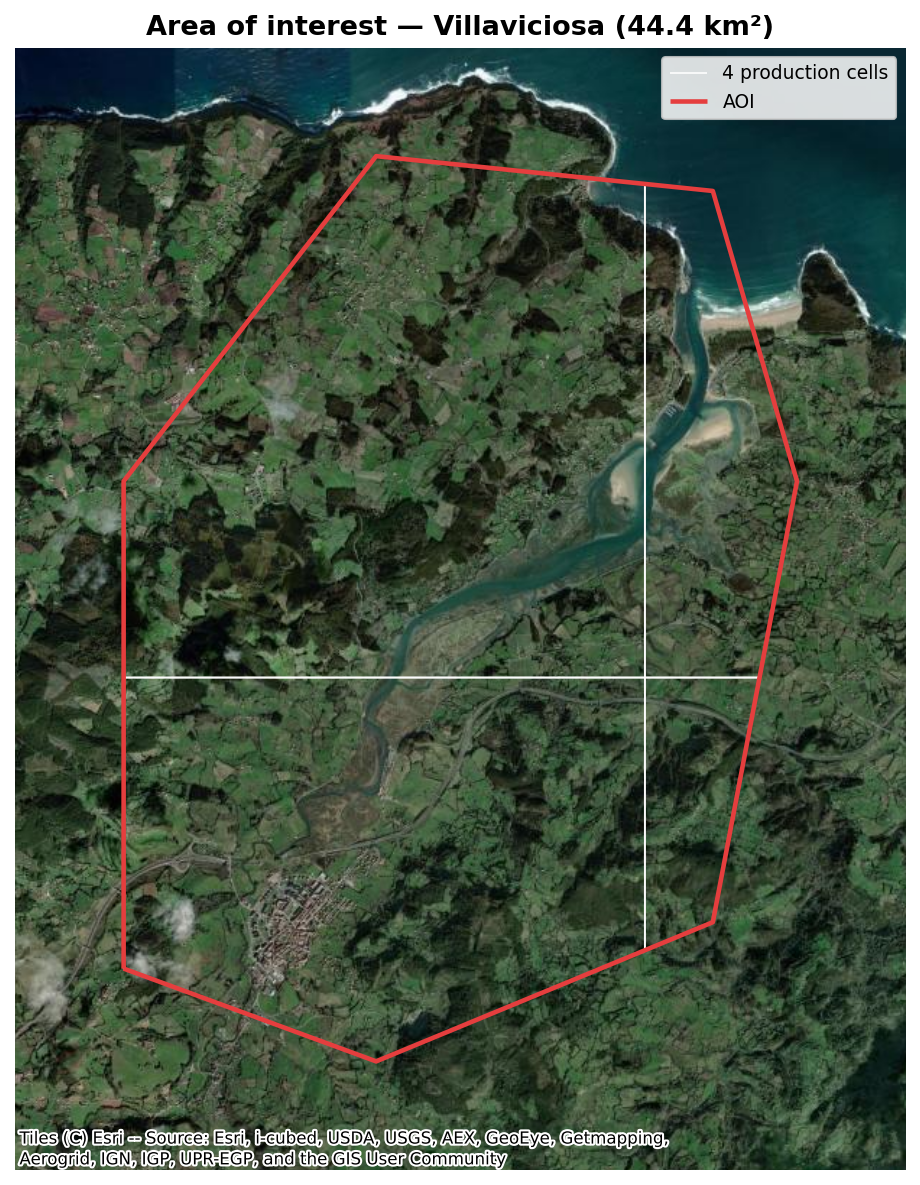

In [4]:
# Where the study area actually is. Over satellite imagery, because the first
# question about any AOI is whether it covers the estuary you meant and stops
# where you meant it to. The outline is the POLYGON, never the bounding box.
# `tiles=` overlays the production cells so the regional split can be checked
# before launching one notebook per cell.
viz.plot_aoi(aoi, tiles=tiles)

## 2 · The datacube

All the imagery this study needs is downloaded **once** and cached as a
netCDF cube. Every later step streams that file in small time blocks, so
memory stays bounded no matter how long the archive is — a decade of imagery
over 80 km² would be ≈ 8 GB if loaded whole, and we never load it whole.

The bands come from the water detector: NDWI needs B03 and B08 (both native
10 m, which is why NDWI has true 10 m resolution), plus SCL for the cloud
mask.

In [5]:
# ── Parameters ──────────────────────────────────────────────────────────
# TIME_EXTENT and CACHE come from the parameters cell at the top; these two
# are properties of the method, not of the area, so they stay here.
WATER         = "ndwi"                          # ndwi | mndwi | awei | scl
RESOLUTION_M  = 10                              # native for B03/B08

# ── Acquisition ─────────────────────────────────────────────────────────
cube = SentinelCube(aoi, TIME_EXTENT, water=WATER,
                    cache_path=CACHE, resolution=RESOLUTION_M)
cube.ensure(conn)          # downloads only if the cache does not exist

transform, crs = cube.grid
print(f"{len(cube.dates)} scenes · grid {cube.shape[0]}×{cube.shape[1]} "
      f"@ {abs(transform.a):g} m · {crs}")
print(f"first {cube.dates[0]} · last {cube.dates[-1]}")


[cube] using cache ndwi_cube_villaviciosa_grande_10y.nc


1379 scenes · grid 915×915 @ 10 m · EPSG:32630
first 2016-01-01 · last 2025-12-29


In [6]:
# What the archive actually offers here. The revisit statistics matter more
# than the raw count: a decade with one long gap is not the same archive as a
# decade sampled evenly, and those gaps are what later decide which epochs can
# be fitted at all. Open "Every date" for the full listing.
explain.dates_available(cube.dates, TIME_EXTENT)

<pyintertidal summary — display it in a notebook>

What is actually inside that cube — bands as rows, time as columns, filled with real (heavily downsampled) imagery so the clouds and tide states are visible:

In [7]:
explain.describe_cube(cube, with_data=True, max_columns=6)

<pyintertidal diagram: Villaviciosa · 2016-01-01 → 2025-12-31 · water=ndwi — display it in a notebook or call .save(path)>

In [8]:
explain.summarize(cube)

,Array,Chunk
Bytes,6.45 GiB,128.00 KiB
Shape,"(3, 1,379, 915, 915)","(3, 1, 256, 256)"
Chunks,"66,192 on disk",1×256×256
Streaming,110.18 MiB in RAM,23 dates/pass
Data type,int16 numpy.ndarray,
band,(band) <U3,'B03' 'B08' 'SCL'
t,(time) datetime64,2016-01-01 2016-01-11 2016-01-18 ... 2025-12-26 2025-12-28 2025-12-29
y,(y) float64,"4,824,840 … 4,815,690"
x,(x) float64,"301,020 … 310,170"
crs,,EPSG:32630


We record the rest of the analysis so that, at the end, the notebook can
draw the process graph that produced every number in it.

In [9]:
log = explain.OpLog("Villaviciosa 2016–2025")
log.record("acquire datacube", kind="acquire",
           params={"water": WATER, "resolution_m": RESOLUTION_M},
           outputs=["cube"],
           note=f"{len(cube.dates)} scenes, cached once")

Operation(name='acquire datacube', kind='acquire', params={'water': 'ndwi', 'resolution_m': 10}, inputs=[], outputs=['cube'], before=None, after=None, note='1379 scenes, cached once', seconds=0.0)

## 3 · Water detection threshold

NDWI separates water from land, but the optimal cut is site-dependent:
turbid estuarine water sits lower than the textbook 0.0. Rather than guessing,
we let the data decide with Otsu's method over the clearest scenes, and then
look at the number before adopting it.

In [10]:
# ── Calibration: let the data suggest the threshold ─────────────────────
# `calibrate_threshold` ranks the archive by cloudiness, pools the clear-sky
# NDWI of the clearest scenes and returns Otsu's split of that sample. A
# result pinned at the ends of the allowed range is a warning, not an answer.
otsu, info = pit.water.calibrate_threshold(cube, n_scenes=12)

# ── Parameter (adopted explicitly, informed by the calibration) ──────────
NDWI_THRESHOLD = 0.0     # turbid estuarine water sits below the textbook 0.1
print()
print(f"adopted NDWI threshold: {NDWI_THRESHOLD:+.3f}  "
      f"(a pixel counts as water when NDWI exceeds this)")

[water] Otsu on 409,121 clear pixels from 12 scenes → +0.250  (clipped — the sample was not clearly bimodal; set the threshold manually)

adopted NDWI threshold: +0.000  (a pixel counts as water when NDWI exceeds this)


## 4 · Coastal stability and cloud screening

Two products from two streaming passes:

1. **Reference map** — each pixel voted wet/dry across the CLEAN scenes and
   labelled stable water, stable land or *transition*. The transition class is
   the intertidal candidate zone.
2. **Per-date cloudiness** — measured globally for clear scenes and, for
   cloudy ones, **inside the transition zone only**. That distinction is what
   rescues dates: a scene can be 80 % cloudy overall and perfectly clear over
   the estuary.

In [11]:
# ── Parameters ──────────────────────────────────────────────────────────
CLEAN_SCENE_MAX_BAD  = 0.05   # a scene votes in the reference map if <5% cloud
STABLE_THRESHOLD     = 0.95   # 95% of votes agree → stable water/land
TRANSITION_BUFFER_PX = 10     # safety halo around the transition zone
BAD_CLASSES          = pit.water.BAD_CLASSES     # SCL cloud/shadow classes

# ── Reference map + per-date cloudiness ─────────────────────────────────
reference_map, cloud_pct = pit.reference_and_clouds(
    cube,
    threshold=NDWI_THRESHOLD,
    bad_classes=BAD_CLASSES,
    clean_scene_max_bad=CLEAN_SCENE_MAX_BAD,
    stable_threshold=STABLE_THRESHOLD,
    transition_buffer_px=TRANSITION_BUFFER_PX,
)

px_km2 = abs(transform.a * transform.e) / 1e6
for code, name in [(0, "transition"), (1, "stable water"), (2, "stable land")]:
    n = int((reference_map == code).sum())
    print(f"  class {code} ({name:13s}): {n:>8,} px  {n * px_km2:6.2f} km²")

log.record("reference map + cloud stats", kind="reduce",
           params={"stable_threshold": STABLE_THRESHOLD,
                   "buffer_px": TRANSITION_BUFFER_PX},
           inputs=["cube"], outputs=["reference map", "cloud %"])

  class 0 (transition   ):  116,011 px   11.60 km²
  class 1 (stable water ):   24,924 px    2.49 km²
  class 2 (stable land  ):  696,290 px   69.63 km²


Operation(name='reference map + cloud stats', kind='reduce', params={'stable_threshold': 0.95, 'buffer_px': 10}, inputs=['cube'], outputs=['reference map', 'cloud %'], before=None, after=None, note='', seconds=0.0)

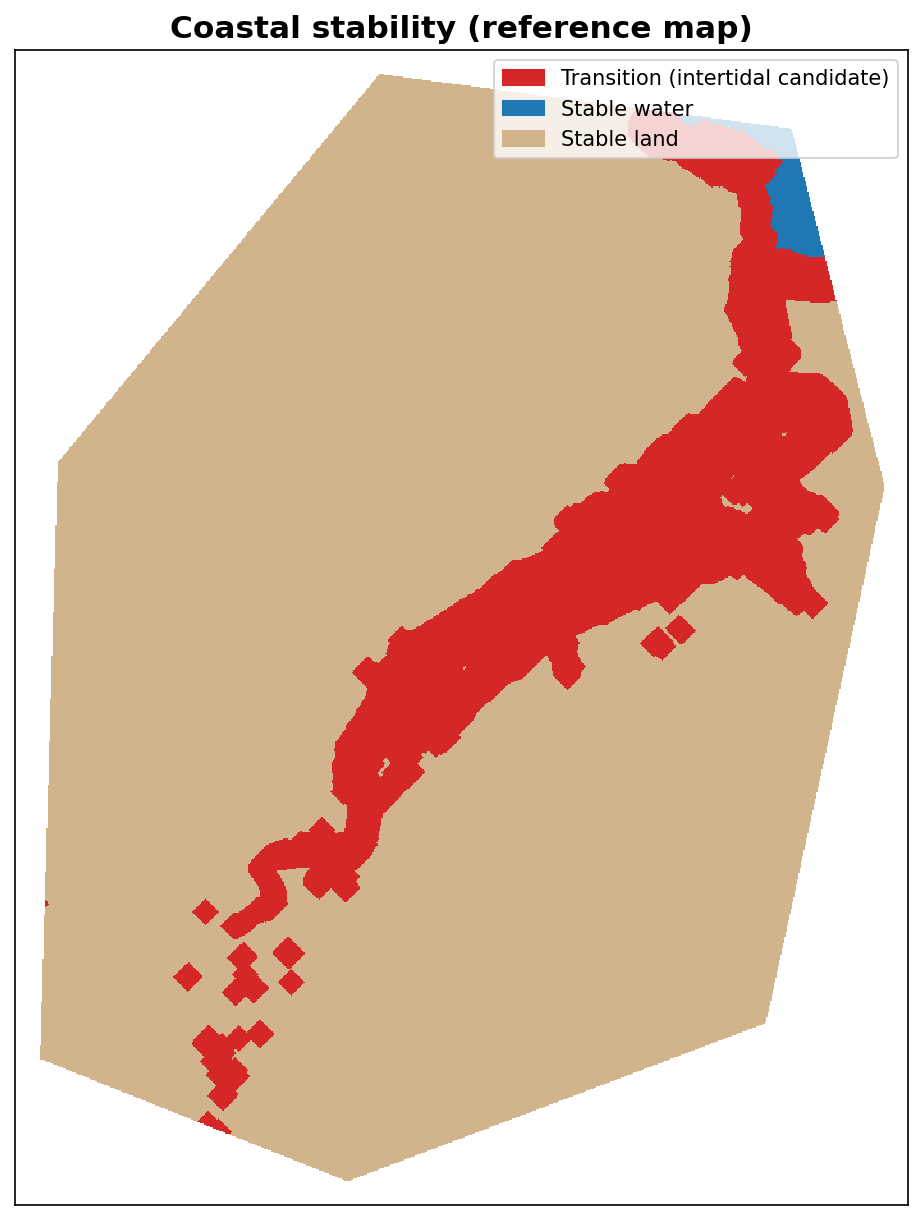

In [12]:
viz.plot_reference_map(reference_map, transform, crs, aoi);

Now the date filter. We keep the dates that are clear **over the transition zone**, and measure how many that rescues compared with a whole-scene filter:

In [13]:
# ── Parameter ───────────────────────────────────────────────────────────
CLOUD_THRESHOLD = 0.10        # ≤10% cloud over the transition zone

usable_dates = pit.filter_dates(cloud_pct, cloud_threshold=CLOUD_THRESHOLD)
gain = pit.date_recovery_gain(cloud_pct,
                              clean_scene_max_bad=CLEAN_SCENE_MAX_BAD,
                              cloud_threshold=CLOUD_THRESHOLD)

log.record("filter dates", kind="filter",
           params={"cloud_threshold": CLOUD_THRESHOLD},
           outputs=[f"{len(usable_dates)} dates"],
           note=f"+{gain['gain_relative_pct']:.0f}% vs a global filter")

[dates] 1379 acquisitions → 281 clear scenes (20%) → 305 usable after the transition-zone filter (22%)
        24 dates recovered (+9% more observations)


Operation(name='filter dates', kind='filter', params={'cloud_threshold': 0.1}, inputs=[], outputs=['305 dates'], before=None, after=None, note='+9% vs a global filter', seconds=0.0)

In [14]:
# Which dates survived and, more to the point, WHY. Three outcomes:
#   [ref]  clean over the whole scene, so it votes in the reference map
#   [✓]    too cloudy globally but clear over the transition zone — an
#          observation a whole-scene filter would have thrown away
#   [✗]    cloudy where it matters
explain.cloud_screening(cloud_pct, usable_dates,
                        clean_scene_max_bad=CLEAN_SCENE_MAX_BAD,
                        cloud_threshold=CLOUD_THRESHOLD)

[ref],2016-01-01,0.0 %
[✓],2016-01-11,6.3 %
[✗],2016-01-18,10000.0 %
[✗],2016-01-21,9922.4 %
[✗],2016-02-10,10000.0 %
[✗],2016-02-17,10000.0 %
[✗],2016-03-11,9297.6 %
[✓],2016-03-18,283.5 %
[✗],2016-03-21,10000.0 %
[✗],2016-03-28,10000.0 %
[✗],2016-04-07,10000.0 %


What that filter did to the cube — same dimensions, fewer labels:

In [15]:
explain.draw_operation(
    "filter dates · clouds ≤ 10% over the transition zone",
    kind="filter",
    before={"bands": cube.bands, "n_dates": len(cube.dates), "shape": cube.shape},
    after={"bands": cube.bands, "n_dates": len(usable_dates), "shape": cube.shape},
    note=f"{len(cube.dates):,} → {len(usable_dates):,} dates",
    params={"cloud_threshold": CLOUD_THRESHOLD})

<pyintertidal diagram: filter dates · clouds ≤ 10% over the transition zone — display it in a notebook or call .save(path)>

## 5 · Water frequency and the intertidal zone

Water frequency is the fraction of clear observations in which each pixel was
wet. Stable water sits near 1, stable land near 0, and the intertidal zone
spans the middle — ordered by elevation, because higher flats flood less
often.

`min_obs` guards against pixels with too little evidence: a pixel seen twice
can report a frequency of 1.0 and mean nothing.

In [16]:
# ── Parameters ──────────────────────────────────────────────────────────
MIN_OBS = max(8, round(0.05 * len(usable_dates)))   # ≥8, or 5% of the archive
print(f"a pixel needs at least {MIN_OBS} clear observations")

# ── Water frequency (streamed over the usable dates) ────────────────────
water_freq = pit.water_frequency(
    cube, dates=usable_dates, threshold=NDWI_THRESHOLD, min_obs=MIN_OBS)

valid = np.isfinite(water_freq)
print(f"water frequency computed for {valid.sum():,} px "
      f"({100 * valid.mean():.1f}% of the grid)")

log.record("water frequency", kind="reduce",
           params={"min_obs": MIN_OBS, "threshold": NDWI_THRESHOLD},
           inputs=[f"{len(usable_dates)} dates"], outputs=["water frequency"])

a pixel needs at least 15 clear observations


water frequency computed for 837,181 px (100.0% of the grid)


Operation(name='water frequency', kind='reduce', params={'min_obs': 15, 'threshold': 0.0}, inputs=['305 dates'], outputs=['water frequency'], before=None, after=None, note='', seconds=0.0)

In [17]:
# The product itself: shape, grid, valid pixels and range, on the same panel
# the cube gets. `Valid` is the number to read first — a map can look complete
# and still be mostly NaN.
explain.summarize(water_freq, name="water frequency", transform=transform,
                  crs=crs, long_name="Fraction of clear observations wet")

,Array,Chunk
Bytes,3.19 MiB,
Shape,"(915, 915)",
Valid,"837,181 px (100.0 %)",
Range,0.000 … 1.000,
Data type,float32 numpy.ndarray,
long_name,,Fraction of clear observations wet
resolution,,10 m
extent,,9.15 × 9.15 km
valid_area,,83.72 km²
crs,,EPSG:32630


The time dimension has collapsed: hundreds of dates became one map.

In [18]:
explain.draw_operation(
    "water frequency · fraction of clear observations wet",
    kind="reduce",
    before={"bands": cube.bands, "n_dates": len(usable_dates), "shape": cube.shape},
    after={"bands": ["water frequency"], "n_dates": 1, "shape": cube.shape},
    note=f"{len(usable_dates)} dates → 1 map",
    params={"min_obs": MIN_OBS})

<pyintertidal diagram: water frequency · fraction of clear observations wet — display it in a notebook or call .save(path)>

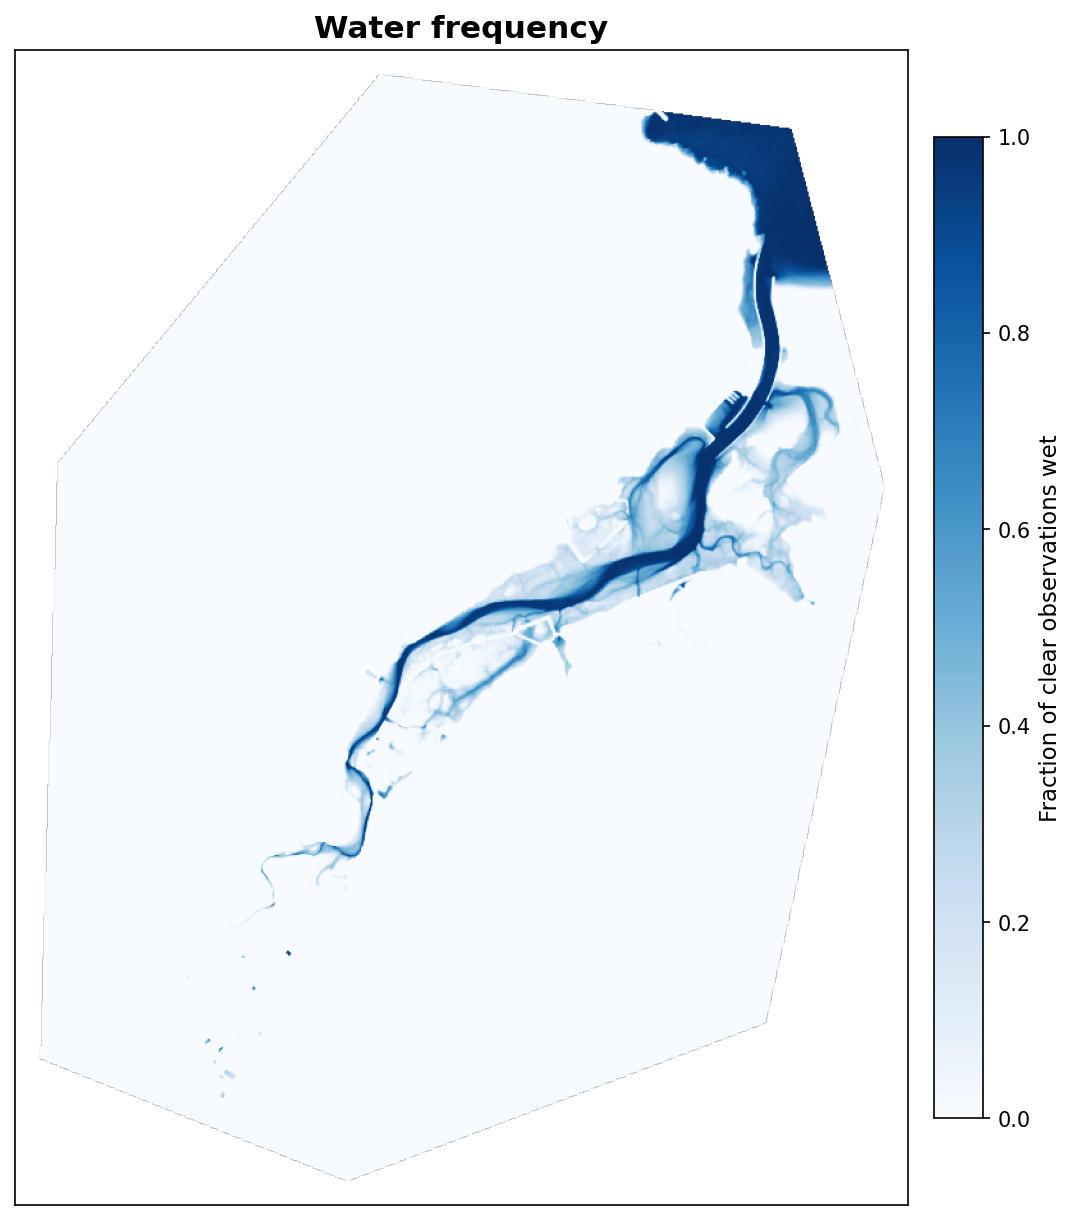

In [19]:
viz.plot_water_frequency(water_freq, transform, crs, aoi);

The intertidal zone is the transition class with a water frequency between
two bounds. The bounds can be pinned by hand, or found from the data: inside
the transition zone the histogram mixes three populations (almost never wet,
truly intertidal, almost always wet) and a 3-class Otsu split finds the two
valleys between them.

In [20]:
# ── Parameters ──────────────────────────────────────────────────────────
transition = reference_map == 0
otsu_low, otsu_high = pit.multiotsu_window(water_freq, transition)
print(f"multi-Otsu suggests the intertidal window "
      f"[{otsu_low:.2f}, {otsu_high:.2f}]")

# Adopted wider than the suggestion, on purpose. Multi-Otsu splits the
# transition histogram into three populations and hands back the two valleys,
# which cuts off the ends of the flat: the lowest ground, wet on almost every
# pass, and the highest, dry on almost every pass. Those ends are real
# intertidal and the fit can resolve them, so the window is opened and the
# per-pixel quality control is left to decide instead.
WF_LOW, WF_HIGH = 0.05, 0.95

# ── Intertidal mask (also clipped to the study polygon) ─────────────────
polygon_mask   = aoi.raster_mask(transform, crs, reference_map.shape)
intertidal     = pit.intertidal_mask(water_freq, reference_map,
                                     WF_LOW, WF_HIGH, aoi_mask=polygon_mask)

area_km2 = intertidal.sum() * px_km2
narrow = pit.intertidal_mask(water_freq, reference_map, otsu_low, otsu_high,
                             aoi_mask=polygon_mask)
print(f"intertidal zone: {int(intertidal.sum()):,} px = {area_km2:.2f} km² "
      f"(the multi-Otsu window would give {int(narrow.sum()):,} px = "
      f"{narrow.sum() * px_km2:.2f} km²)")

log.record("intertidal mask", kind="mask",
           params={"wf_low": WF_LOW, "wf_high": WF_HIGH},
           outputs=["intertidal mask"], note=f"{area_km2:.2f} km²")

multi-Otsu suggests the intertidal window [0.21, 0.66]
intertidal zone: 30,806 px = 3.08 km² (the multi-Otsu window would give 17,822 px = 1.78 km²)


Operation(name='intertidal mask', kind='mask', params={'wf_low': 0.05, 'wf_high': 0.95}, inputs=[], outputs=['intertidal mask'], before=None, after=None, note='3.08 km²', seconds=0.0)

In [21]:
# Where every pixel of the candidate zone ended up. The transition class is
# only a CANDIDATE; the water-frequency window then splits it into ground
# almost never wet, ground almost always wet, and the intertidal proper.
# Reporting the three together is what makes the window a defensible choice
# instead of a magic number — widen it and you see exactly what you gained.
explain.intertidal_breakdown(reference_map, water_freq, intertidal,
                             WF_LOW, WF_HIGH, transform)

,intertidal,"30,806 px",3.08 km²,26.6 %
,terrestrial,"37,492 px",3.75 km²,32.3 %
,aquatic,"28,705 px",2.87 km²,24.7 %


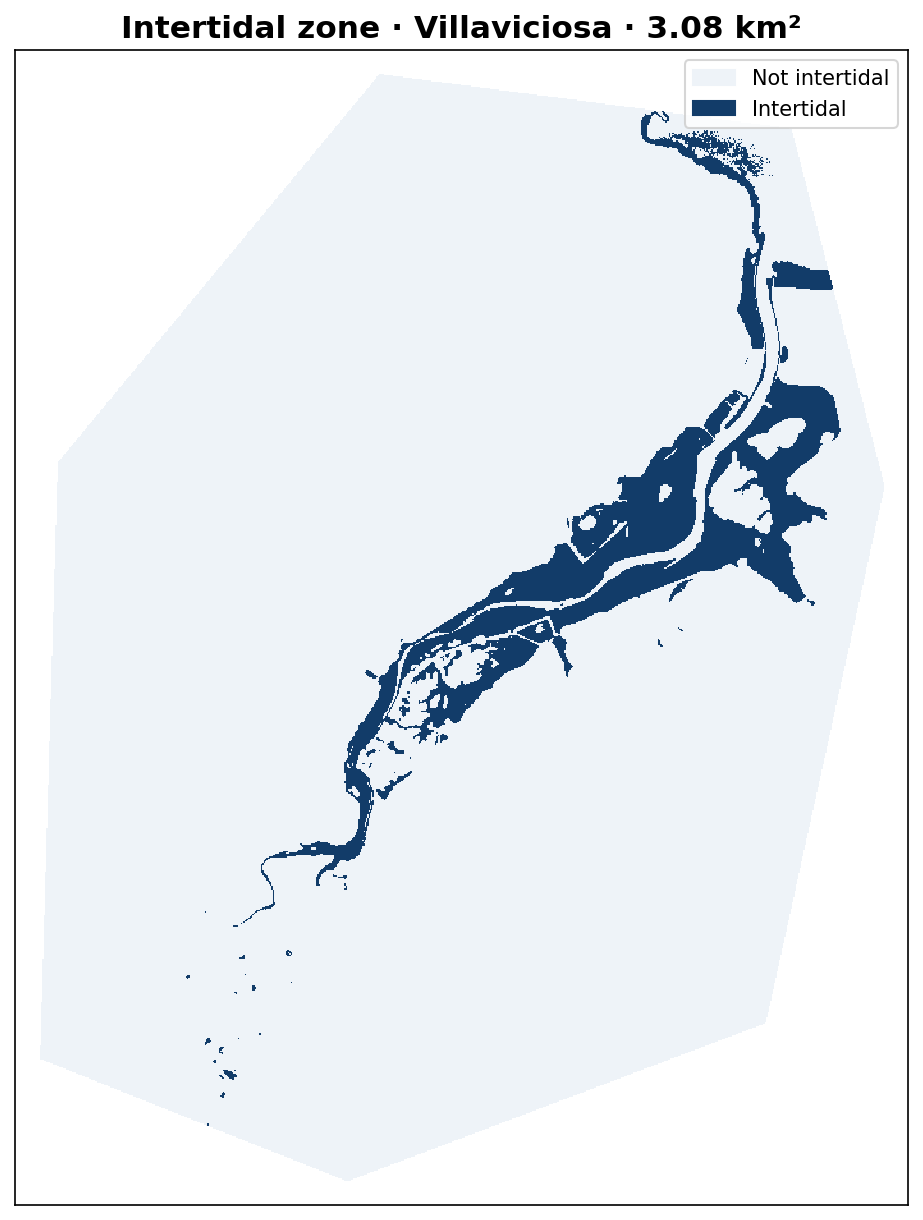

In [22]:
viz.plot_intertidal(intertidal, transform, crs, aoi,
                    title=f"Intertidal zone · {aoi.name} · {area_km2:.2f} km²");

## 6 · Tides

Elevation methods need the water level at the moment each image was taken, so
we pair every usable date with its real acquisition time (from the Copernicus
catalogue) and predict the tide there with a global harmonic model.

Two refinements worth noting. The prediction point defaults to the polygon
centroid, which in a curved estuary can fall on land where the model returns
nothing; `water_centroid` instead picks the middle of the main channel. And
the continuous series (not the satellite dates) is what later drives the
sampling diagnostics and the hydroperiod.

In [23]:
# ── Parameters ──────────────────────────────────────────────────────────
TIDE_MODEL = TIDE_MODEL or (pit.sites.tide_model(SITE) if POLYGON is None
                            else "EOT20")
TIDE_DIR   = "./tide_models"

tide_point = pit.water_centroid(reference_map, transform, crs)
print(f"tide prediction point (mid-channel): "
      f"{tide_point[0]:.4f}, {tide_point[1]:.4f}")

# How far away is the nearest cell where this model predicts anything at all?
# Tide models are defined on an ocean grid and an estuary usually falls on a
# LAND cell, so every implementation searches outward until it finds water —
# silently. Here that search reaches 34 km with GOT4.10 and 13 km with EOT20,
# which is a term in the error budget and belongs in the record.
ocean = pit.tidecheck.nearest_ocean_km(*tide_point, model=TIDE_MODEL,
                                       directory=TIDE_DIR)

tides = TideService(model=TIDE_MODEL, directory=TIDE_DIR, location=tide_point)

# Tide height at each satellite acquisition …
tide_heights = tides.heights_for(aoi, usable_dates)

# … and the continuous series that represents the real tidal regime.
# The full study period, not one year: the tidal frame is a decadal
# quantity. The 18.6-year nodal cycle plus the annual and semiannual terms
# all move the extremes, so a single year understates the frame our
# elevations are referenced to. About a minute of pyTMD for ten years.
series_times, series_heights = tides.series(aoi, TIME_EXTENT[0],
                                            TIME_EXTENT[1], every_hours=1)
print(f"reference series: {len(series_times):,} hourly predictions, "
      f"range [{np.nanmin(series_heights):+.2f}, "
      f"{np.nanmax(series_heights):+.2f}] m")

log.record("tide heights", kind="apply",
           params={"model": TIDE_MODEL,
                   "point": f"{tide_point[0]:.3f},{tide_point[1]:.3f}",
                   "ocean_cell_km": round(ocean["distance_km"], 1)},
           outputs=[f"{len(tide_heights)} tide heights"])


tide prediction point (mid-channel): 43.5403, -5.3810


[tidecheck] EOT20: nearest ocean cell 11.1 km away (1120/2601 probe points wet)


[tides] model EOT20 already cached


[tides] EOT20 @ (43.540, -5.381) → 305 dates, range [-2.27, 1.22] m


reference series: 87,649 hourly predictions, range [-2.39, +2.41] m


Operation(name='tide heights', kind='apply', params={'model': 'EOT20', 'point': '43.540,-5.381', 'ocean_cell_km': 11.1}, inputs=[], outputs=['305 tide heights'], before=None, after=None, note='', seconds=0.0)

## 7 · Is this site mappable?

A satellite in a sun-synchronous orbit does not sample the tide evenly, and no
elevation method can reconstruct a tide level that was never imaged. These
diagnostics put a ceiling on what is achievable here — and belong in the
results, not just in the planning.

In [24]:
sampled = np.array(list(tide_heights.values()))

metrics = pit.coverage.coverage_metrics(sampled, series_heights)
verdict = pit.coverage.coverage_verdict(metrics)
pit.coverage.print_coverage_report(metrics, verdict,
                                   title=f"Tidal sampling · {aoi.name}")


Tidal sampling · Villaviciosa

TIDAL RANGE COVERAGE
  sampled   3.49 m  [-2.27 → +1.22]
  reference 4.79 m  [-2.39 → +2.41]
  coverage  72.8%   (unsampled: 0.12 m low, 1.19 m high)

UNIFORMITY (Kolmogorov–Smirnov)
  statistic 0.2684 · p 0.0000 → significantly non-uniform

ENTROPY
  normalised 0.875 (16/20 height bins occupied)

DISPERSION
  VMR 0.015 → regular spacing

GAPS
  mean 0.011 m · max 0.086 m between -2.17 and -2.09 m

VERTICAL SAMPLING RESOLUTION
  VSR 0.011 m → detailed (305 levels)

REPRESENTATIVITY
  9/10 quantiles sampled (90%)

VERDICT: LIMITED
  - only 73% of the tidal range was imaged (0.12 m missing at the bottom, 1.19 m at the top)


{'n_sampled': 305,
 'n_reference': 87649,
 'range_coverage': {'coverage': 0.7279636790056868,
  'coverage_pct': 72.79636790056868,
  'sampled_range': 3.490198830970173,
  'sampled_min': -2.2699832599279772,
  'sampled_max': 1.2202155710421956,
  'reference_range': 4.794468366522594,
  'reference_min': -2.388025307761624,
  'reference_max': 2.4064430587609693,
  'unsampled_low': 0.1180420478336468,
  'unsampled_high': 1.1862274877187737},
 'uniformity': {'ks_statistic': 0.268387642981476,
  'ks_pvalue': 6.848584507761733e-20,
  'uniform': False,
  'interpretation': 'significantly non-uniform'},
 'entropy': {'entropy': 3.78114289555729,
  'entropy_max': 4.321928094887363,
  'entropy_normalised': 0.8748740868757636,
  'n_bins': 20,
  'bins_occupied': 16,
  'bins_empty': 4},
 'dispersion': {'vmr': 0.01450035821188233,
  'pattern': 'regular',
  'mean_gap': 0.011480917207138727,
  'variance_gap': 0.0001664774121044752},
 'gaps': {'n_gaps': 304,
  'mean_gap': 0.011480917207138727,
  'median_g

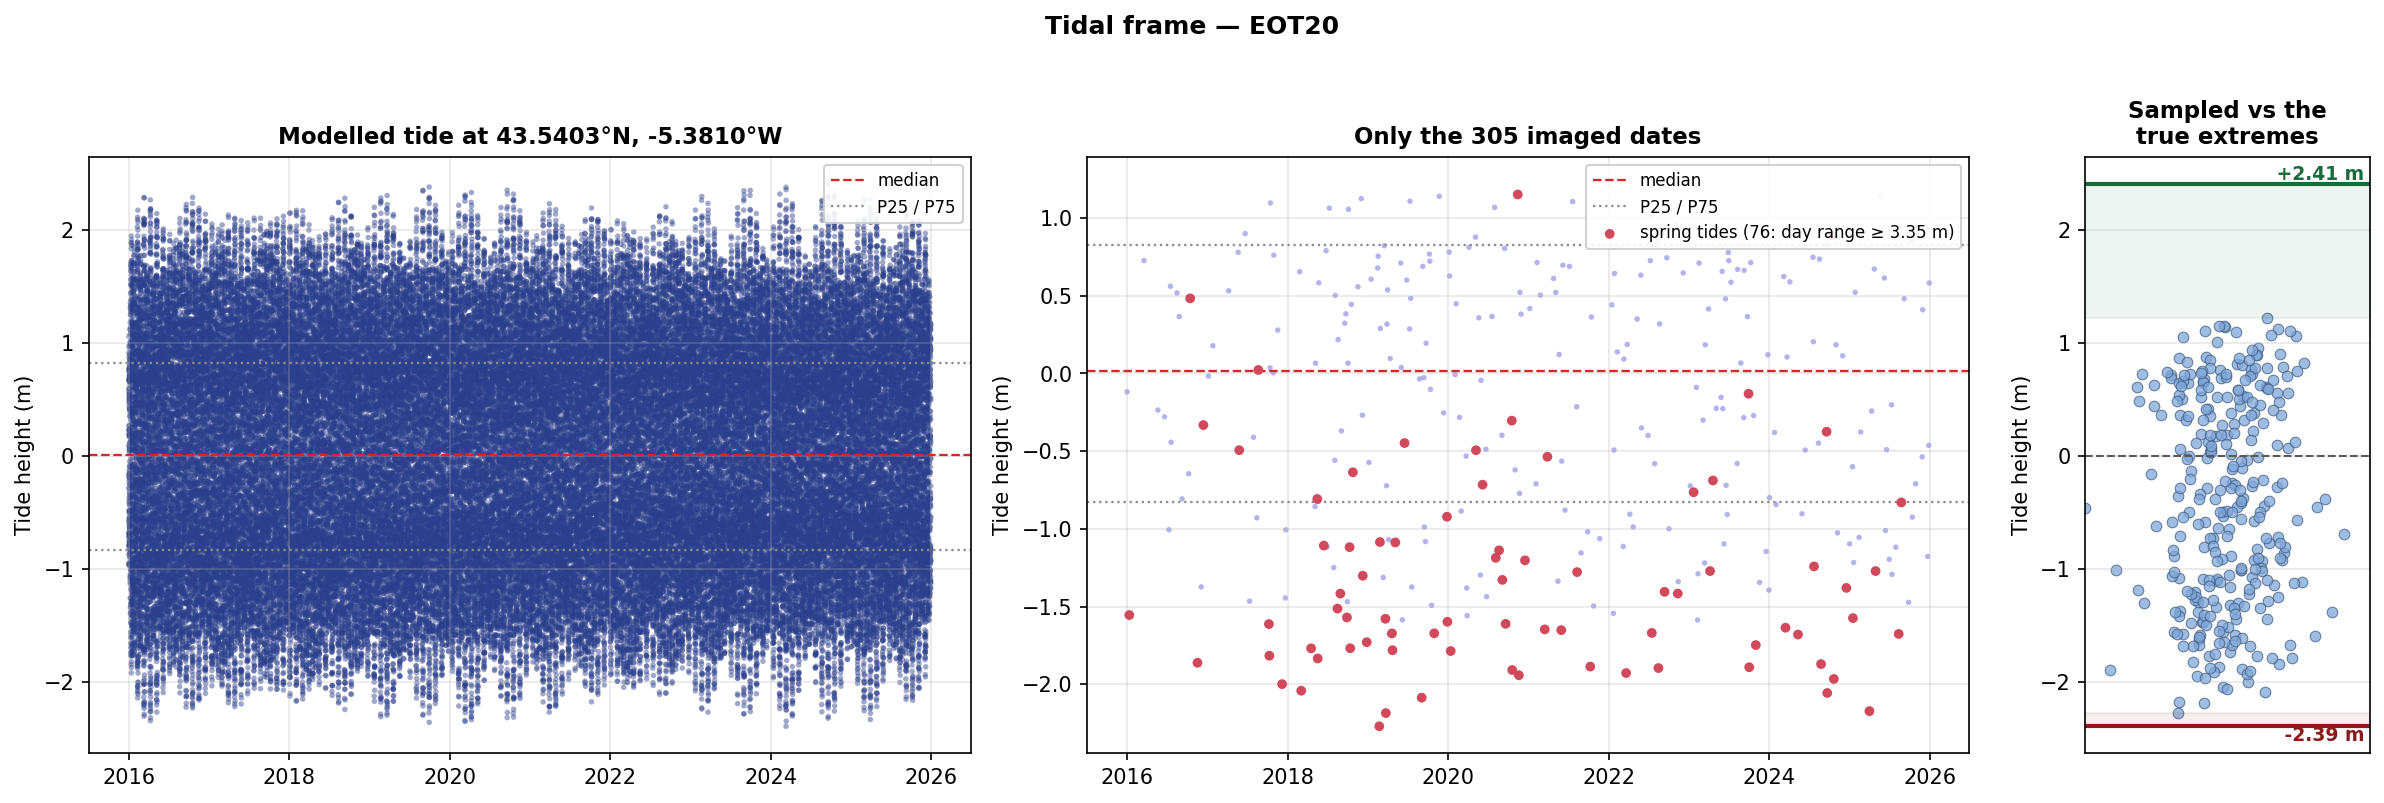

In [25]:
# Three views of the tidal frame over the whole period:
#   left    every modelled tide height — the envelope the estuary experiences
#   centre  only the heights the satellite caught
#   right   those same heights against the true extremes, so the band no
#           image reaches is a distance you can read in metres
sampled_times = pd.to_datetime(sorted(tide_heights))
sampled = np.array([tide_heights[d] for d in sorted(tide_heights)])

viz.plot_tide_record(series_times, series_heights, sampled_times, sampled,
                     model_name=TIDE_MODEL, location=tide_point);

## 7b — MAREA: measuring the tide the model cannot see

Section 6 pinned a term of the error budget: the tide model predicts at an
ocean cell kilometres away, and inside an estuary the tide arrives late and
deformed — minutes of clock error become tens of centimetres of water level
assigned to every scene. MAREA measures that interior tide from the archive
itself:

* every intertidal pixel is a **binary threshold sensor** — wet when the
  water tops its elevation — so its wet/dry sequence records *when* the
  water crossed it;
* the flat is banded by geodesic distance from the mouth, and each band's
  clock lag τ is the one that makes its wet/dry record most probable
  (profiled Bernoulli likelihood: every pixel is granted its best elevation
  and width first, so only the clocks remain as unknowns);
* an exact invariance of that likelihood (the affine theorem) says binary
  data can never recover gain or datum — only **phase** — so those stay
  with the ocean model and only the measurable part is corrected;
* the operator $h(s,t) = h_B(t-	au(s))$ is applied with the lag as measured in
  every band; a negative fitted lag is clipped to 0 by causality, and the
  product says so.

The identifiability of exactly this fit was gated against a calibrated
digital twin, and adoption against a matched null — see
`research/01_interior_tide_identifiability.ipynb` and
`research/03_operator_and_gauges.ipynb`. One call runs the identical
pipeline every campaign cell runs — nothing below is site-specific:

In [ ]:
# The whole interior-tide product in one call: band the flat by geodesic
# distance from the mouth, fit each band's clock, and re-invert every
# elevation with the corrected clock. The record is the one the elevation
# products use (section 9a): the most recent epoch of the usable dates
# (transition-zone cloud screening), at the real overpass instants, with the
# boundary read at the AOI centroid. Writes LAG_DIR/{marea.npz, result.json,
# figure.png, record.json}; the decadal all-scenes run of earlier versions
# stays in products_marea/marea.npz and is no longer read.
import json, os
from pyintertidal.boundary import PyTMDBoundary
EXTRACT = "products_marea/marea_extract.npz"
if os.path.exists(EXTRACT):
    z_ = np.load(EXTRACT, allow_pickle=True)
    ex = {k: z_[k] for k in z_.files}; ex["shape"] = tuple(int(v) for v in ex["shape"])
else:
    ex = pit.marea.extract(cube.cache_path)
    np.savez_compressed(EXTRACT, Y=ex["Y"], C=ex["C"], keep=ex["keep"], dates=ex["dates"],
                        shape=np.array(ex["shape"]), sea=ex["sea"], inter=ex["inter"])
OVERPASS = "products_marea/overpass_times.json"
if os.path.exists(OVERPASS):
    times_ = json.load(open(OVERPASS))
else:
    times_ = pit.overpass.get_overpass_times({**aoi.bbox, "crs": "EPSG:4326"}, TIME_EXTENT, verbose=False)
    json.dump({k: str(v) for k, v in times_.items()}, open(OVERPASS, "w"))   # instants as text
latest = pit.epochs(sorted(tide_heights), epoch_years=3)[-1]   # the same call as section 8
LAG_DIR = f"products_marea/marea_eot20_g0_{latest['label']}"
dates_m = np.array([str(d) for d in ex["dates"]])
in_epoch = np.isin(dates_m, list(latest["dates"])) & np.array([d in times_ for d in dates_m])
t_lag = pd.DatetimeIndex(pd.to_datetime([times_[d] for d in dates_m[in_epoch]])).tz_localize(None)
bnd = PyTMDBoundary(TIDE_MODEL or "EOT20", *aoi.centroid, directory="tide_models")
okh_lag = np.isfinite(np.asarray(bnd.levels(t_lag), float))
rec_lag = np.flatnonzero(in_epoch)[okh_lag]
ex_lag = {**ex, "Y": ex["Y"][rec_lag], "C": ex["C"][rec_lag], "dates": ex["dates"][rec_lag],
          "bbox": {**aoi.bbox, "crs": "EPSG:4326"}}
marea_res = pit.marea.reconstruct(cube.cache_path, out_dir=LAG_DIR, name=aoi.name,
                                  boundary=bnd, extraction=ex_lag,
                                  overpass_times=times_, min_scenes=40)
assert marea_res is not None and marea_res["estado"] == "ok", "reconstruct refused the record"
assert marea_res["n_escenas"] == len(rec_lag)
json.dump({"dates": [str(d) for d in ex["dates"][rec_lag]], "epoch": latest["label"],
           "boundary": bnd.name if hasattr(bnd, "name") else "EOT20 at aoi.centroid"},
          open(f"{LAG_DIR}/record.json", "w"), indent=1)
print(f"scenes in the MAREA record ({latest['label']}): {marea_res['n_escenas']}")
print(f"pixels inverted: {marea_res['n_px_cota']:,} / {marea_res['n_px']:,}")
print(f"interior tide adopted: {marea_res['con_operador']}")

In [ ]:
# The measured clocks: one lag per band of distance from the mouth, with
# its 95 % scene-bootstrap interval, and the smoothed profile every pixel
# actually received (Gaussian kernel of the band length, anchored at 0).
from pyintertidal import tide_estimators as te
centres = np.asarray(marea_res["centros_km"])
tau_used = np.asarray(marea_res["tau_usado_min"])
tau_lo, tau_hi = np.asarray(marea_res["tau_lo_min"]), np.asarray(marea_res["tau_hi_min"])
mp_ = np.load(f"{LAG_DIR}/marea.npz")
BAND_KM = float(mp_["band_km"][0])
s_grid = np.linspace(0, float(marea_res["s_max_km"]), 200)
tau_curve = te.smooth_lag_profile(centres, tau_used, s_grid, bandwidth_km=BAND_KM)
plt.figure(figsize=(7.5, 4.2))
plt.errorbar(centres, tau_used, yerr=[np.clip(tau_used - tau_lo, 0, None), np.clip(tau_hi - tau_used, 0, None)],
             fmt="o", color="#1a76b3", capsize=4, label="lag per band (95 % bootstrap interval)")
plt.plot(s_grid, tau_curve, "-", color="crimson", lw=2, label=f"lag applied per pixel (kernel {BAND_KM:.0f} km)")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("distance from the mouth  s  (km)")
plt.ylabel("cotidal lag  (min)")
plt.title("The interior tide, measured from the imagery alone")
plt.legend(); plt.grid(alpha=0.3);


## 8 · Elevation

Our estimator, **HSR**, uses the physics of mixed pixels. A 10 m pixel on the
waterline is *partially* flooded, so its NDWI is the mixture of its wet and dry
parts, and as the tide rises the wet fraction traces the pixel's internal
hypsometry. Fitting that sigmoid per pixel gives three things at once:

* **μ** — the elevation (the whole curve is used, so no threshold crossing);
* **σ** — the relief *inside* the pixel, a sub-pixel product;
* **σ(μ)** — a Cramér–Rao uncertainty, offered as quality control.

Fitted per **epoch**, not per decade: intertidal morphology migrates, and
fitting ten years at once blurs the transition. Measured here on the same
pixels with only the time window changed, σ is pinned at the widest value the
grid offers for **15.6 %** of pixels over ten years against **10.8 %** over
three, and the median fit residual drops from **0.215 to 0.191** NDWI. The
three-year fit also resolves slightly *more* pixels (33 313 against 31 487),
so the shorter window costs no coverage.

> **Read the uncertainty with caution.** A split-half test (the dates halved
> into two sets with matched tidal coverage, fitted independently) puts the
> typical pixel's repeatability at ~5 cm, but the Cramér–Rao value predicts
> ~3 cm where ~10 cm is observed, and does not separate stable pixels from
> unstable ones within the bulk of the distribution. It is not yet calibrated;
> treat it as indicative. See section 9.


In [28]:
# ── Parameters ───────────────────────────────────────────────────
EPOCH_YEARS     = 3       # morphology is stable enough within ~3 years
SCALE           = 4       # super-resolution factor: 10 m → 2.5 m
MAX_UNCERTAINTY = 0.10    # drop pixels whose σ(μ) exceeds 10 cm
SIGMA_FLOOR     = 0.05    # noise floor of σ, not injected as relief
TIDE_BINS       = "auto"  # from this archive's own tide sampling
MIN_REGION_PX   = 25      # blank isolated specks (25 px at 10 m = 0.25 ha)

epoch_list = pit.epochs(sorted(tide_heights), epoch_years=EPOCH_YEARS)
for e in epoch_list:
    print(f"  epoch {e['label']}: {len(e['dates'])} dates")

latest = epoch_list[-1]
print(f"\nfitting the most recent epoch: {latest['label']}")

# ── HSR fit (local: no cloud job) ─────────────────────────────────
# `tide_bins` averages every observation sharing a tide level before fitting:
# scene noise is independent of tide height while the signal is a function of
# it, so averaging cancels one and keeps the other.
#
# The COUNT is not a free choice. Too few bins quantise the tide axis until a
# pixel's whole transition fits inside one bin and its elevation stops being
# identifiable there; too many average nothing. Measured on the Tagus against
# a real bathymetric survey: 40 bins gave RMSE 0.339 m with 39 % of pixels
# pinned at the bottom of the σ grid, no binning gave 0.289 m, and the optimum
# near 150 bins gave 0.275 m. "auto" derives the count from the tide sampling
# of this archive, which is what sets that balance.
dem = pit.fit_hsr(
    cube, tide_heights,
    dates=latest["dates"],
    scale=SCALE,
    sigma_floor=SIGMA_FLOOR,
    max_uncertainty=MAX_UNCERTAINTY,
    clip_mask=intertidal,
    epoch_label=latest["label"],
    tide_bins=TIDE_BINS,
)

# A per-pixel fit makes per-pixel decisions, so a few isolated pixels far
# from the estuary can pass on their own. Real flats are contiguous.
before = int(np.isfinite(dem.mu).sum())
dem.mu = pit.terrain.drop_small_regions(dem.mu, min_region_px=MIN_REGION_PX)
print(f"\ndespeckled: {before:,} → {int(np.isfinite(dem.mu).sum()):,} px")
dem.summary()

log.record("HSR elevation", kind="apply",
           params={"epoch": latest["label"], "scale": SCALE,
                   "tide_bins": TIDE_BINS,
                   "max_uncertainty": MAX_UNCERTAINTY},
           inputs=[f"{len(latest['dates'])} dates", "tide heights"],
           outputs=["elevation", "sub-pixel relief", "uncertainty"])

  epoch 2016-2016: 16 dates

  epoch 2017-2019: 101 dates

  epoch 2020-2022: 91 dates

  epoch 2023-2025: 97 dates


fitting the most recent epoch: 2023-2025

[hsr] tide_bins='auto' → 30 bins (11.06 cm each)

C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:360: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(block, axis=0)


[hsr] filas 32/915 ( 3.5 %)  13:14:07  faltan ~8.9 min

[hsr] filas 64/915 ( 7.0 %)  13:14:29  faltan ~9.0 min

[hsr] filas 96/915 (10.5 %)  13:14:45  faltan ~8.2 min

[hsr] filas 128/915 (14.0 %)  13:15:07  faltan ~8.1 min

[hsr] filas 160/915 (17.5 %)  13:15:27  faltan ~7.8 min

[hsr] filas 192/915 (21.0 %)  13:15:45  faltan ~7.3 min

[hsr] filas 224/915 (24.5 %)  13:15:59  faltan ~6.7 min

[hsr] filas 256/915 (28.0 %)  13:16:15  faltan ~6.3 min

[hsr] filas 288/915 (31.5 %)  13:16:33  faltan ~6.0 min

[hsr] filas 320/915 (35.0 %)  13:16:48  faltan ~5.6 min

[hsr] filas 352/915 (38.5 %)  13:17:04  faltan ~5.2 min

[hsr] filas 384/915 (42.0 %)  13:17:19  faltan ~4.9 min

[hsr] filas 416/915 (45.5 %)  13:17:35  faltan ~4.5 min

[hsr] filas 448/915 (49.0 %)  13:17:52  faltan ~4.2 min

[hsr] filas 480/915 (52.5 %)  13:18:09  faltan ~3.9 min

[hsr] filas 512/915 (56.0 %)  13:18:25  faltan ~3.6 min

[hsr] filas 544/915 (59.5 %)  13:18:42  faltan ~3.3 min

[hsr] filas 576/915 (63.0 %)  13:19:00  faltan ~3.1 min

[hsr] filas 608/915 (66.4 %)  13:19:16  faltan ~2.8 min

[hsr] filas 640/915 (69.9 %)  13:19:31  faltan ~2.5 min

[hsr] filas 672/915 (73.4 %)  13:19:46  faltan ~2.2 min

[hsr] filas 704/915 (76.9 %)  13:20:02  faltan ~1.9 min

[hsr] filas 736/915 (80.4 %)  13:20:19  faltan ~1.6 min

[hsr] filas 768/915 (83.9 %)  13:20:35  faltan ~1.3 min

[hsr] filas 800/915 (87.4 %)  13:20:50  faltan ~1.0 min

[hsr] filas 832/915 (90.9 %)  13:21:01  faltan ~0.7 min

[hsr] filas 864/915 (94.4 %)  13:21:15  faltan ~0.4 min

[hsr] filas 896/915 (97.9 %)  13:21:30  faltan ~0.2 min

[hsr] filas 915/915 (100.0 %)  13:21:53  faltan ~0.0 min


despeckled: 25,833 → 25,496 px

[hsr · 2023-2025] 25,496 px

  elevation [-2.06, 1.03] m

  sub-pixel relief σ: median 15 cm | saturated 8%

  uncertainty: median 2.3 cm

Operation(name='HSR elevation', kind='apply', params={'epoch': '2023-2025', 'scale': 4, 'tide_bins': 'auto', 'max_uncertainty': 0.1}, inputs=['97 dates', 'tide heights'], outputs=['elevation', 'sub-pixel relief', 'uncertainty'], before=None, after=None, note='', seconds=0.0)

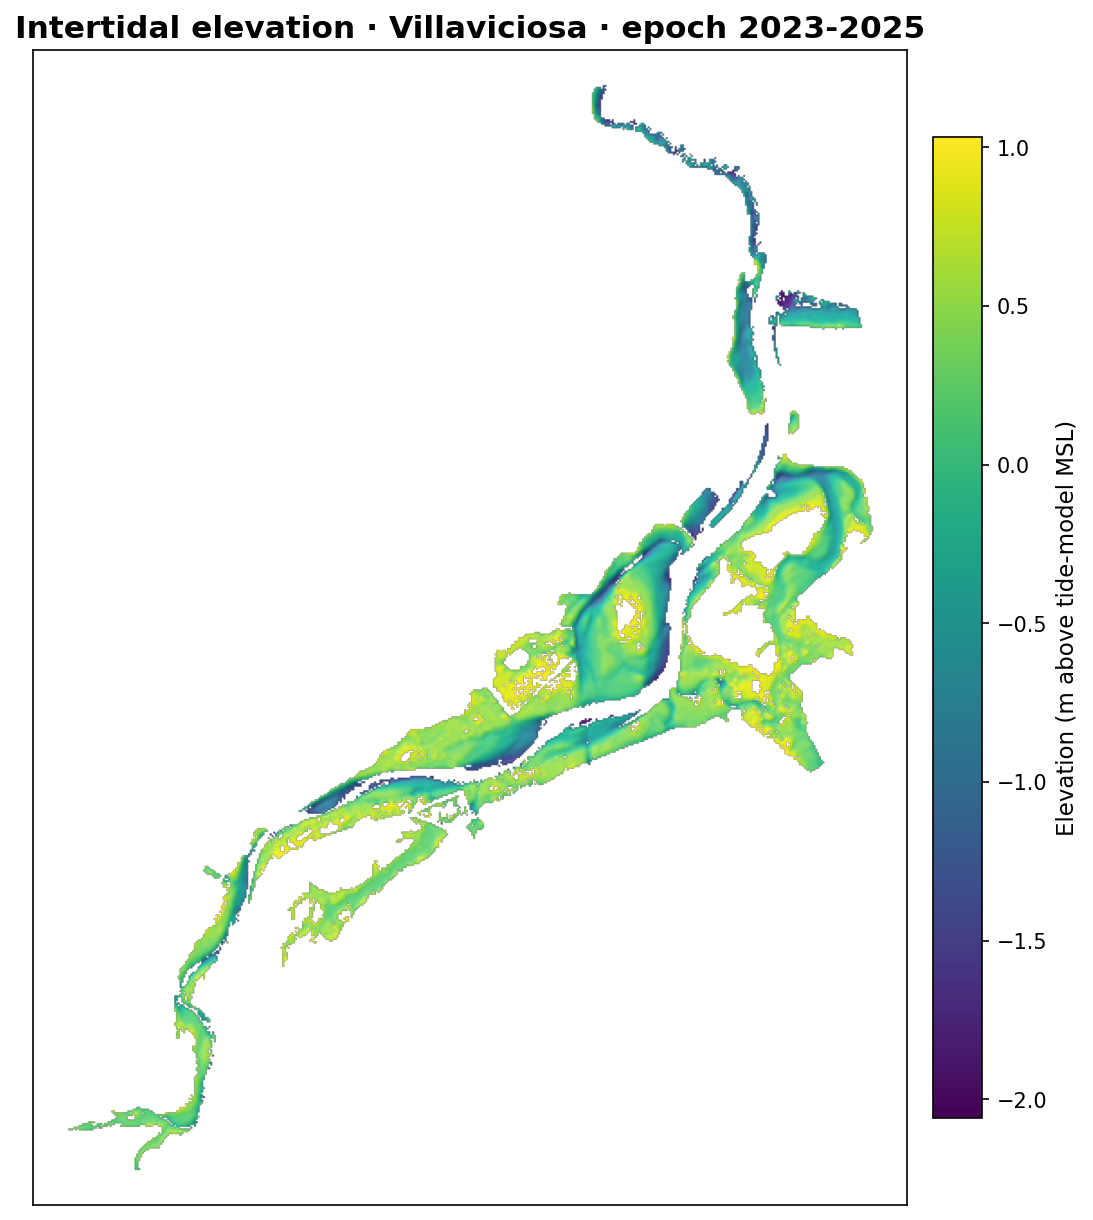

In [29]:
viz.plot_dem(dem.mu, transform, crs, aoi,
             title=f"Intertidal elevation · {aoi.name} · epoch {dem.epoch}");

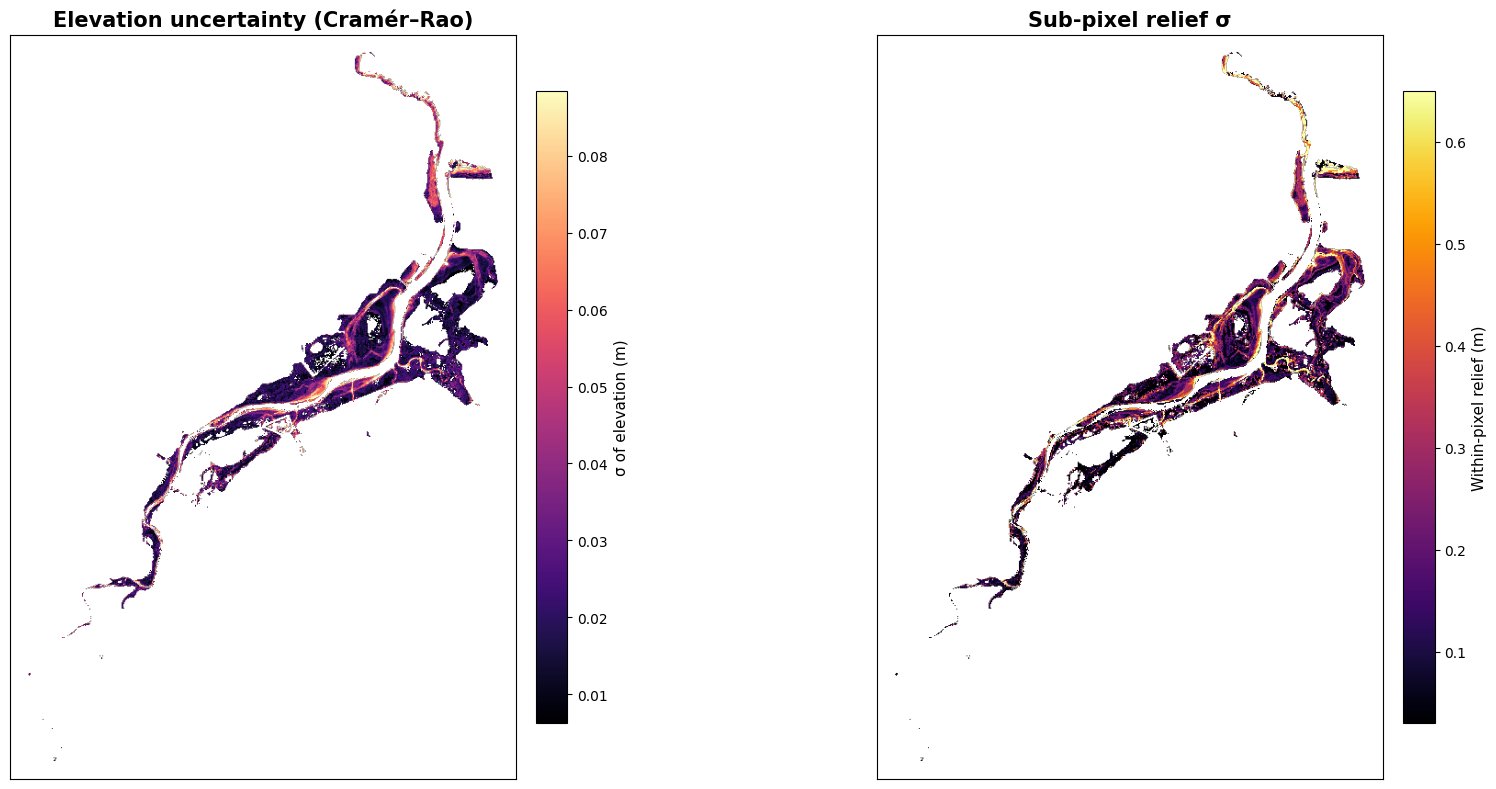

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(19, 8))
viz.plot_uncertainty(dem.sigma_mu, transform, crs, aoi,
                     title="Elevation uncertainty (Cramér–Rao)", ax=axes[0])
viz.plot_subpixel_relief(dem.sigma, transform, crs, aoi,
                         title="Sub-pixel relief σ", ax=axes[1])
fig.tight_layout();

### The published baseline, for comparison

The DEA-style **step** method reads the tide at which the rolling median of
NDWI crosses from dry to wet. It is more selective than HSR — it needs a clean
monotonic transition — and provides no uncertainty, but it is the reference
method of the literature and runs from the same cube.

In [31]:
dem_step = pit.fit_step(
    cube, tide_heights, dates=latest["dates"],
    threshold=NDWI_THRESHOLD, min_obs=5,
    clip_mask=intertidal, epoch_label=latest["label"],
)
dem_step.mu = pit.terrain.drop_small_regions(dem_step.mu,
                                             min_region_px=MIN_REGION_PX)
dem_step.summary()

print(f"\\ncoverage: HSR {int(np.isfinite(dem.mu).sum()):,} px vs "
      f"step {int(np.isfinite(dem_step.mu).sum()):,} px")

C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:995: RuntimeWarning: All-NaN slice encountered
  m_ = np.nanmedian(block, axis=0)


C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:1018: RuntimeWarning: All-NaN slice encountered
  z = np.nanmin(wet_tide, axis=0)


C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:1019: RuntimeWarning: All-NaN slice encountered
  t_hi = np.nanmax(med_tide, axis=0)


C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:1020: RuntimeWarning: All-NaN slice encountered
  t_lo = np.nanmin(med_tide, axis=0)


[step] filas 32/915  13:30:19

[step] filas 64/915  13:30:50

[step] filas 96/915  13:31:24

[step] filas 128/915  13:31:55

[step] filas 160/915  13:32:24

[step] filas 192/915  13:32:46

[step] filas 224/915  13:33:14

[step] filas 256/915  13:33:39

[step] filas 288/915  13:34:04

[step] filas 320/915  13:34:35

[step] filas 352/915  13:35:03

[step] filas 384/915  13:35:26

[step] filas 416/915  13:35:48

[step] filas 448/915  13:36:14

[step] filas 480/915  13:36:39

[step] filas 512/915  13:37:15

[step] filas 544/915  13:37:44

[step] filas 576/915  13:38:07

[step] filas 608/915  13:38:40

[step] filas 640/915  13:39:04

[step] filas 672/915  13:39:25

[step] filas 704/915  13:39:45

[step] filas 736/915  13:40:05

[step] filas 768/915  13:40:28

[step] filas 800/915  13:40:45

[step] filas 832/915  13:41:04

[step] filas 864/915  13:41:21

[step] filas 896/915  13:41:38

[step] filas 915/915  13:41:52

[step · 2023-2025] 19,132 px

  elevation [-1.96, 0.70] m

C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:737: RuntimeWarning: All-NaN slice encountered
  f"{np.nanmedian(self.sigma[v]) * 100:.0f} cm | "


  sub-pixel relief σ: median nan cm | saturated 0%

C:\Users\Jorge\sketch_fitton\Intertidal_analysis\pyintertidal\elevation.py:740: RuntimeWarning: All-NaN slice encountered
  f"{np.nanmedian(self.sigma_mu[v]) * 100:.1f} cm")


  uncertainty: median nan cm

\ncoverage: HSR 25,496 px vs step 19,132 px

## 9 · Validation

Two blocks, both on the three products of the tide-adjustment comparison
(**no delay**, **MAREA**, **Granadeiro**): the RTK-GNSS survey on site, and
the IGN LiDAR as the external reference. Nothing else is compared here.

### 9a · On site: the RTK-GNSS survey against the three products

The same three products the tide-adjustment comparison uses, on the surveyed
pixels: **no delay** (our sigmoid inversion with the boundary read at the
overpass time), **MAREA** (the same inversion with the band clocks the
product applied) and **Granadeiro** (their NIR logistic with their own lag
map, produced by `experiments/sota_granadeiro.py` and loaded here). Two
views, both on the **development subset** of the survey (the reserved blocks
stay sealed): an OLS line of each product on the RTK elevation, and the
profile along the surveyed transect. Every score is median-centred: the
products sit on the tide model's datum and the survey on the ellipsoid.


In [ ]:
import json, os
from pyintertidal import elevation_validation as ev
from pyintertidal.boundary import PyTMDBoundary
from pyproj import Transformer

rtk_rows = {}
if FIELD_CSV is None:
    print("no field survey configured for this run — section skipped")
else:
    # ── the wet/dry record MAREA used, cached next to its product ────────
    EXTRACT = "products_marea/marea_extract.npz"
    if os.path.exists(EXTRACT):
        z_ = np.load(EXTRACT, allow_pickle=True)
        ex = {k: z_[k] for k in z_.files}; ex["shape"] = tuple(int(v) for v in ex["shape"])
    else:
        ex = pit.marea.extract(cube.cache_path)
        np.savez_compressed(EXTRACT, Y=ex["Y"], C=ex["C"], keep=ex["keep"], dates=ex["dates"],
                            shape=np.array(ex["shape"]), sea=ex["sea"], inter=ex["inter"])
    keep_m = ex["keep"]
    assert tuple(ex["shape"]) == tuple(cube.shape), "extraction grid differs from the cube grid"
    mp = np.load(f"{LAG_DIR}/marea.npz")         # the lag fitted on this same record (section 7b)
    assert np.array_equal(mp["keep"], keep_m), "the MAREA product and the extraction disagree on the pixels"
    tau_px_m = mp["tau_px_min"].astype(float)      # the lag every pixel received

    # ── the epoch of the elevation products, at the real overpass instants ─
    bb_ = {**aoi.bbox, "crs": "EPSG:4326"}
    OVERPASS = "products_marea/overpass_times.json"
    if os.path.exists(OVERPASS):
        times_ = json.load(open(OVERPASS))
    else:
        times_ = pit.overpass.get_overpass_times(bb_, TIME_EXTENT, verbose=False)
        json.dump({k: str(v) for k, v in times_.items()}, open(OVERPASS, "w"))   # instants as text
    dates_m = np.array([str(d) for d in ex["dates"]])
    in_epoch = np.isin(dates_m, list(latest["dates"])) & np.array([d in times_ for d in dates_m])
    t_real = pd.DatetimeIndex(pd.to_datetime([times_[d] for d in dates_m[in_epoch]])).tz_localize(None)
    lat_c, lon_c = aoi.centroid
    bnd = PyTMDBoundary(TIDE_MODEL or aoi.tide_model, lat_c, lon_c, directory="tide_models")
    h0 = np.asarray(bnd.levels(t_real), float)
    okh = np.isfinite(h0)
    Y_e = np.nan_to_num(ex["Y"][in_epoch][okh], nan=0.0).astype(np.float32)
    C_e = ex["C"][in_epoch][okh].astype(np.float32)
    t_real, h0 = t_real[okh], h0[okh]
    lo_, hi_ = float(h0.min()), float(h0.max())
    print(f"record for the {latest['label']} epoch: {len(t_real)} scenes × {Y_e.shape[1]:,} px")

    # ── the three products on the record ─────────────────────────────────
    def to_raster_m(vals):
        r = np.full(cube.shape[0] * cube.shape[1], np.nan, np.float32); r[keep_m] = vals
        return r.reshape(cube.shape)
    z_nodelay, _ = pit.marea.invert_series(Y_e, C_e, h0, lo_, hi_)
    z_mareaclk = np.full(len(keep_m), np.nan)
    for tv in np.unique(tau_px_m):
        sel = np.flatnonzero(tau_px_m == tv)
        h_k = (np.asarray(bnd.levels(t_real - pd.Timedelta(minutes=float(tv))), float) if tv else h0)
        z_mareaclk[sel], _ = pit.marea.invert_series(Y_e[:, sel], C_e[:, sel], h_k, lo_, hi_)
    three = {"no delay": to_raster_m(z_nodelay), "MAREA": to_raster_m(z_mareaclk)}
    GRAN = "granadeiro_products_2023-2025.npz"
    if os.path.exists(GRAN):
        g_ = np.load(GRAN)
        if np.array_equal(g_["keep"], keep_m):
            zg = g_["final"].astype(float); zg[zg == -9999] = np.nan
            three["Granadeiro"] = to_raster_m(zg)
        else:
            print(f"{GRAN} is on other pixels: Granadeiro row skipped")
    else:
        print(f"{GRAN} not found (run experiments/sota_granadeiro.py): Granadeiro row skipped")
    print("lags applied on the record:", len(np.unique(tau_px_m)), "distinct values, "
          f"median {np.median(tau_px_m):.0f} min, max {tau_px_m.max():.0f} min")

    # ── the survey, development subset only ──────────────────────────────
    dev_ = pit.rtk.load_rtk(FIELD_CSV)
    r_, c_, z_rtk = dev_["row"], dev_["col"], dev_["elev"]
    print(f"{len(z_rtk)} development RTK pixels ({dev_['n_reserved_hidden']} reserved, sealed)")
    fits_ = {name: ev.ols_against_truth(z_rtk, ras[r_, c_]) for name, ras in three.items()}
    np.savez_compressed("products_marea/external_products.npz",
                        **{k.replace(" ", "_"): v for k, v in three.items()})
    print("-> products_marea/external_products.npz (the scored maps)")
    rtk_rows = {name: {k: v for k, v in (f or {}).items() if k not in ("x", "y")} for name, f in fits_.items()}
    rtk_table = pd.DataFrame([{"product": n, **r} for n, r in rtk_rows.items()])
    display(rtk_table[["product", "n", "rmse_m", "slope", "r", "bias_m"]].round(3))

    # ── OLS lines and the transect profile ───────────────────────────────
    east_ = transform.c + (c_ + 0.5) * transform.a
    north_ = transform.f + (r_ + 0.5) * transform.e
    order_, dist_ = ev.transect_order(east_, north_)
    colours_ = {"no delay": "0.45", "MAREA": "crimson", "Granadeiro": "#1a76b3"}
    fig = plt.figure(figsize=(15, 9))
    gs_ = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.8])
    for j, (name, f) in enumerate(fits_.items()):
        ax = fig.add_subplot(gs_[0, j])
        if f is None:
            ax.set_title(f"({'abc'[j]}) {name}: too few common pixels", loc="left"); continue
        ax.plot(f["x"], f["y"], ".", ms=4, color=colours_[name], alpha=0.7)
        lim_ = [min(f["x"].min(), f["y"].min()) - 0.1, max(f["x"].max(), f["y"].max()) + 0.1]
        ax.plot(lim_, lim_, "-", color="0.75", lw=0.8)
        xx_ = np.array(lim_); ax.plot(xx_, f["intercept"] + f["slope"] * xx_, "-", color="#14313c", lw=1.4)
        ax.set_xlim(lim_); ax.set_ylim(lim_); ax.set_aspect("equal")
        ax.set_title(f"({'abc'[j]}) {name}", loc="left")
        ax.set_xlabel("RTK elevation (m, centred)"); ax.set_ylabel("product elevation (m, centred)")
        ax.text(0.03, 0.97, f"n = {f['n']}\nRMSE {f['rmse_m']:.3f} m\nslope {f['slope']:.2f}\nr {f['r']:.2f}",
                transform=ax.transAxes, va="top", bbox=dict(boxstyle="round", fc="white", ec="0.7"))
        ax.grid(alpha=0.3)
    ax = fig.add_subplot(gs_[1, :])
    ax.plot(dist_, z_rtk[order_] - np.nanmedian(z_rtk), "o", ms=4, color="#ff5da2", label="RTK-GNSS (development points)", zorder=5)
    for name, ras in three.items():
        v_ = ras[r_, c_][order_]
        ax.plot(dist_, v_ - np.nanmedian(v_), "-", lw=1.4, color=colours_[name], label=name)
    ax.set_xlabel("distance along the surveyed transect (m)"); ax.set_ylabel("elevation (m, each series centred)")
    ax.set_title("(d) profile along the transect", loc="left"); ax.legend(ncol=4); ax.grid(alpha=0.3)
    fig.tight_layout()
    os.makedirs("products_marea", exist_ok=True)
    rtk_table.to_csv("products_marea/rtk_onsite_metrics.csv", index=False)


### 9b · External: the IGN LiDAR against the three products

The same three products against the IGN 5 m LiDAR DTM (PNOA), on the
intertidal pixels each resolves and on the pixels all three resolve. The
reference's own behaviour over the flats is stated first: the share of cells
holding one repeated value is the share that is a water surface at flight
time, not a bed, and it bounds what these scores can mean.


In [33]:
lidar, lidar_rows, rows = None, {}, []       # `rows` is what the report cell expects
if MDT_PATH is None:
    print("no LiDAR reference configured for this run — section skipped")
elif not rtk_rows:
    print("no products on the record — section skipped")
else:
    pit.download_mdt_ign({**aoi.bbox, "crs": "EPSG:4326"}, MDT_PATH)
    lidar = pit.reproject_to_grid(MDT_PATH, transform, crs, reference_map.shape)
    print(f"LiDAR reprojected onto the analysis grid: {np.isfinite(lidar).mean() * 100:.0f}% coverage")
    inter_m = np.zeros(cube.shape[0] * cube.shape[1], bool); inter_m[keep_m] = True
    inter_m = inter_m.reshape(cube.shape)
    diag_ = ev.lidar_diagnostic(lidar, inter_m)
    print(f"LiDAR over the intertidal record: {diag_['n']:,} cells, {diag_['distinct_values']} distinct values, "
          f"mode {diag_['mode_m']:+.2f} m holding {diag_['share_within_tol_of_mode']:.0%} of the cells (within 5 cm)")
    # only reference inside the tide range the products could sample
    # (scene levels ±0.25 m): a quay or a cliff inside a mixed shoreline
    # pixel is not something a waterline product can or should represent
    in_range_m = inter_m & (lidar >= lo_ - 0.25) & (lidar <= hi_ + 0.25)
    print(f"{int((inter_m & np.isfinite(lidar) & ~in_range_m).sum()):,} cells outside the products' tide range "
          f"[{lo_:+.2f}, {hi_:+.2f}] m excluded; {int(in_range_m.sum()):,} scored")
    l_all, l_common, n_common = ev.score_products(three, lidar, in_range_m)
    np.savez_compressed("products_marea/external_products.npz", lidar=lidar, intertidal=inter_m,
                        **{k.replace(" ", "_"): v for k, v in three.items()})
    lidar_rows = l_all
    lidar_table = pd.DataFrame([{"product": k, **(r or {}),
                                 "common RMSE (m)": (l_common[k] or {}).get("rmse_m", np.nan),
                                 "common slope": (l_common[k] or {}).get("slope", np.nan)}
                                for k, r in l_all.items()])
    print(f"common subset: {n_common:,} px")
    display(lidar_table.round(3))
    lidar_table.to_csv("products_marea/lidar_external_metrics.csv", index=False)


LiDAR reprojected onto the analysis grid: 100% coverage

LiDAR over the intertidal record: 32,120 cells, 427 distinct values, mode +2.00 m holding 69% of the cells (within 5 cm)

23,490 cells outside the products' tide range [-2.17, +1.15] m excluded; 8,630 scored

common subset: 4,297 px

,product,n,rmse_m,slope,intercept,r,bias_m,common RMSE (m),common slope
0,no delay,7528,0.815,0.458,-0.203,0.339,-0.818,0.751,0.408
1,MAREA,7458,0.803,0.467,-0.157,0.335,-0.862,0.760,0.421
2,Granadeiro,4477,0.775,0.322,-0.001,0.246,-0.527,0.767,0.328


## 10 · From topography to habitat

Elevation is a means, not an end. What organises intertidal life is the
**hydroperiod**: the fraction of time a spot is submerged. Computing it from
the continuous tide series (not from the satellite dates, which are unevenly
sampled) turns our DEM into an ecological map.

In [34]:
hydro = pit.hydroperiod.hydroperiod(dem.mu, series_heights)
zones, zone_labels = pit.hydroperiod.zonation(dem.mu, series_heights)
zone_table = pit.hydroperiod.zone_areas(zones, zone_labels, transform)

print(f"hydroperiod: {np.nanmin(hydro):.0%} – {np.nanmax(hydro):.0%} "
      f"of the time submerged (median {np.nanmedian(hydro):.0%})\n")
pd.DataFrame(zone_table)

hydroperiod: 18% – 100% of the time submerged (median 44%)


,zone,code,pixels,area_km2,percent
0,subtidal,1,617,0.062,2.4
1,lower intertidal,2,7121,0.712,27.9
2,mid intertidal,3,16880,1.688,66.2
3,upper intertidal,4,878,0.088,3.4
4,supratidal,5,0,0.000,0.0


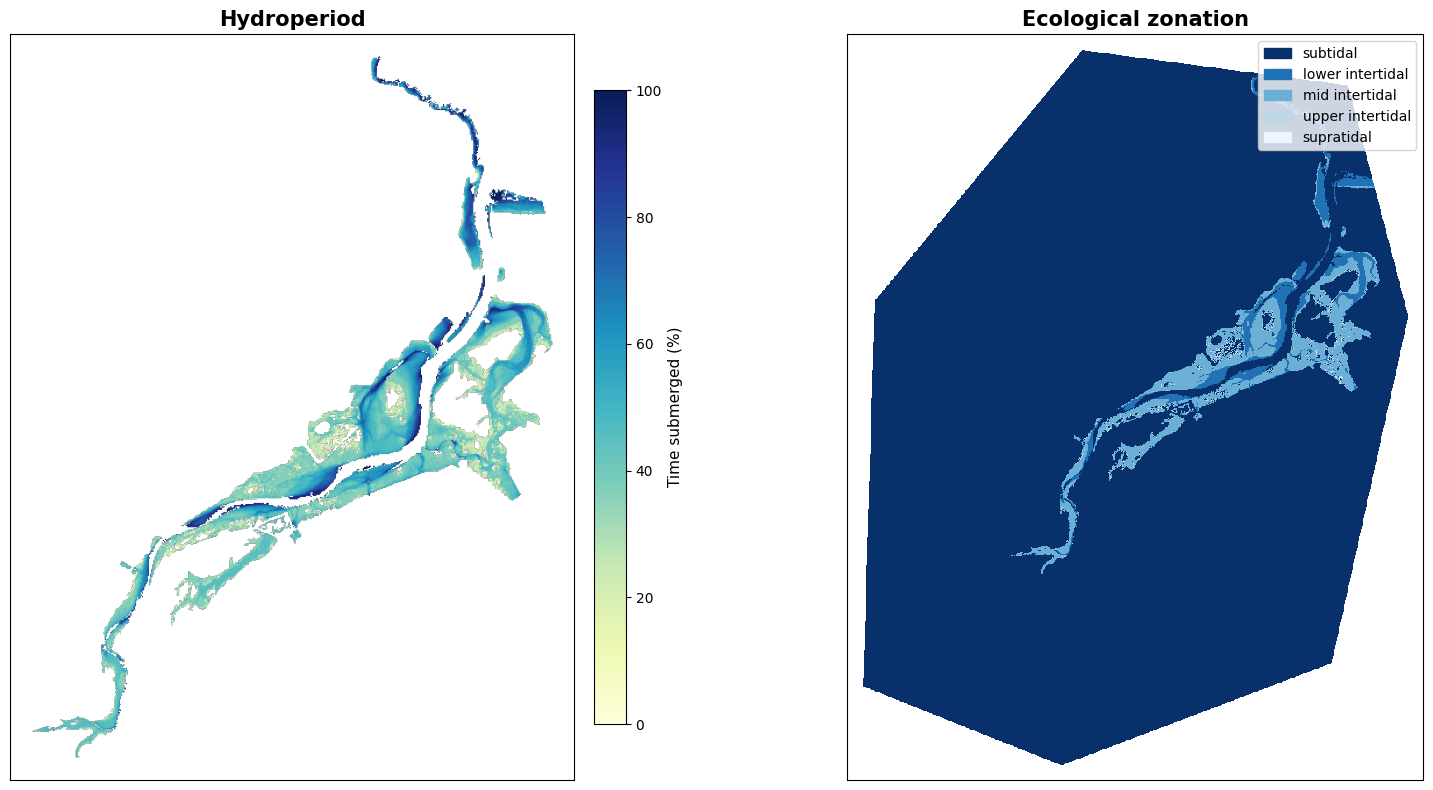

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(19, 8))
viz.plot_map(hydro * 100, transform, crs, aoi, cmap="YlGnBu",
             vmin=0, vmax=100, robust=False,
             title="Hydroperiod", cbar_label="Time submerged (%)", ax=axes[0])
viz.plot_map(zones.astype(float), transform, crs, aoi,
             classes={c: (zone_labels[c], col) for c, col in
                      zip(sorted(zone_labels)[1:],
                          ["#08306b", "#2171b5", "#6baed6", "#bdd7e7", "#eff3ff"])},
             title="Ecological zonation", ax=axes[1])
fig.tight_layout();

### Morphological signature

The hypsometric curve — how much area lies below each elevation — is the
compact fingerprint of the estuary's shape, and the natural quantity to
compare between epochs or between sites.

[hypsometry] Villaviciosa

  intertidal area   2.55 km²

  elevation range   -2.06 … +1.03 m (median +0.25)

  hypsometric integral 0.705 → convex — area concentrated high (accretional signature)

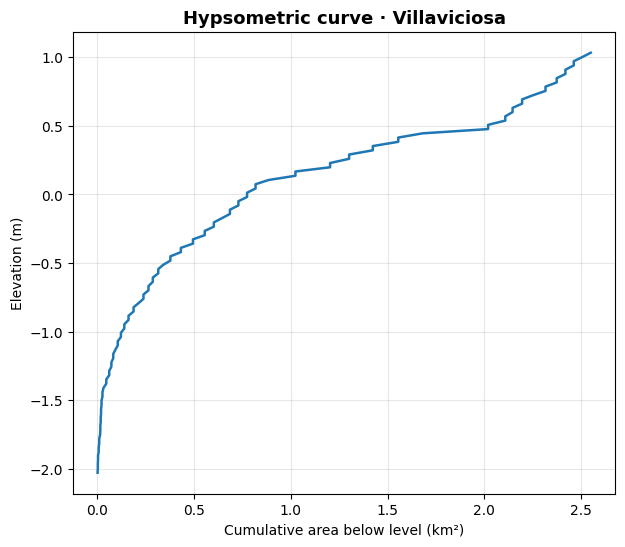

In [36]:
curve = pit.hypsometry.hypsometric_curve(dem.mu, transform)
summary = pit.hypsometry.describe(curve, aoi.name)

pit.hypsometry.plot_curves({aoi.name: curve},
                           title=f"Hypsometric curve · {aoi.name}");

### Change between epochs

With two epochs fitted, the difference is a change map. The rule that keeps it
honest: **never subtract two DEMs without their uncertainties**. Only changes
larger than the propagated uncertainty are reported.

comparing 2020-2022 → 2023-2025

[hsr] filas 32/915 ( 3.5 %)  13:46:16  faltan ~36.5 min

[hsr] filas 64/915 ( 7.0 %)  13:47:33  faltan ~34.8 min

[hsr] filas 96/915 (10.5 %)  13:48:50  faltan ~33.2 min

[hsr] filas 128/915 (14.0 %)  13:49:59  faltan ~31.1 min

[hsr] filas 160/915 (17.5 %)  13:51:08  faltan ~29.2 min

[hsr] filas 192/915 (21.0 %)  13:52:20  faltan ~27.8 min

[hsr] filas 224/915 (24.5 %)  13:53:54  faltan ~27.6 min

[hsr] filas 256/915 (28.0 %)  13:55:05  faltan ~26.1 min

[hsr] filas 288/915 (31.5 %)  13:56:27  faltan ~25.1 min

[hsr] filas 320/915 (35.0 %)  13:57:58  faltan ~24.2 min

[hsr] filas 352/915 (38.5 %)  13:59:13  faltan ~22.8 min

[hsr] filas 384/915 (42.0 %)  14:00:30  faltan ~21.5 min

[hsr] filas 416/915 (45.5 %)  14:01:42  faltan ~20.1 min

[hsr] filas 448/915 (49.0 %)  14:02:56  faltan ~18.8 min

[hsr] filas 480/915 (52.5 %)  14:04:14  faltan ~17.5 min

[hsr] filas 512/915 (56.0 %)  14:05:20  faltan ~16.1 min

[hsr] filas 544/915 (59.5 %)  14:06:23  faltan ~14.6 min

[hsr] filas 576/915 (63.0 %)  14:07:26  faltan ~13.2 min

[hsr] filas 608/915 (66.4 %)  14:08:31  faltan ~11.9 min

[hsr] filas 640/915 (69.9 %)  14:09:34  faltan ~10.6 min

[hsr] filas 672/915 (73.4 %)  14:10:37  faltan ~9.3 min

[hsr] filas 704/915 (76.9 %)  14:11:40  faltan ~8.0 min

[hsr] filas 736/915 (80.4 %)  14:12:42  faltan ~6.8 min

[hsr] filas 768/915 (83.9 %)  14:13:44  faltan ~5.5 min

[hsr] filas 800/915 (87.4 %)  14:14:45  faltan ~4.3 min

[hsr] filas 832/915 (90.9 %)  14:15:45  faltan ~3.1 min

[hsr] filas 864/915 (94.4 %)  14:16:43  faltan ~1.9 min

[hsr] filas 896/915 (97.9 %)  14:17:41  faltan ~0.7 min

[hsr] filas 915/915 (100.0 %)  14:18:22  faltan ~0.0 min

[morphodynamics] 2020-2022 → 2023-2025

  17,929 of 23,758 pixels changed significantly (75%) at 1.96σ

  accretion +102,383 m³ over 0.37 km²

  erosion   -306,620 m³ over 1.42 km²

  net       -204,237 m³ → eroding

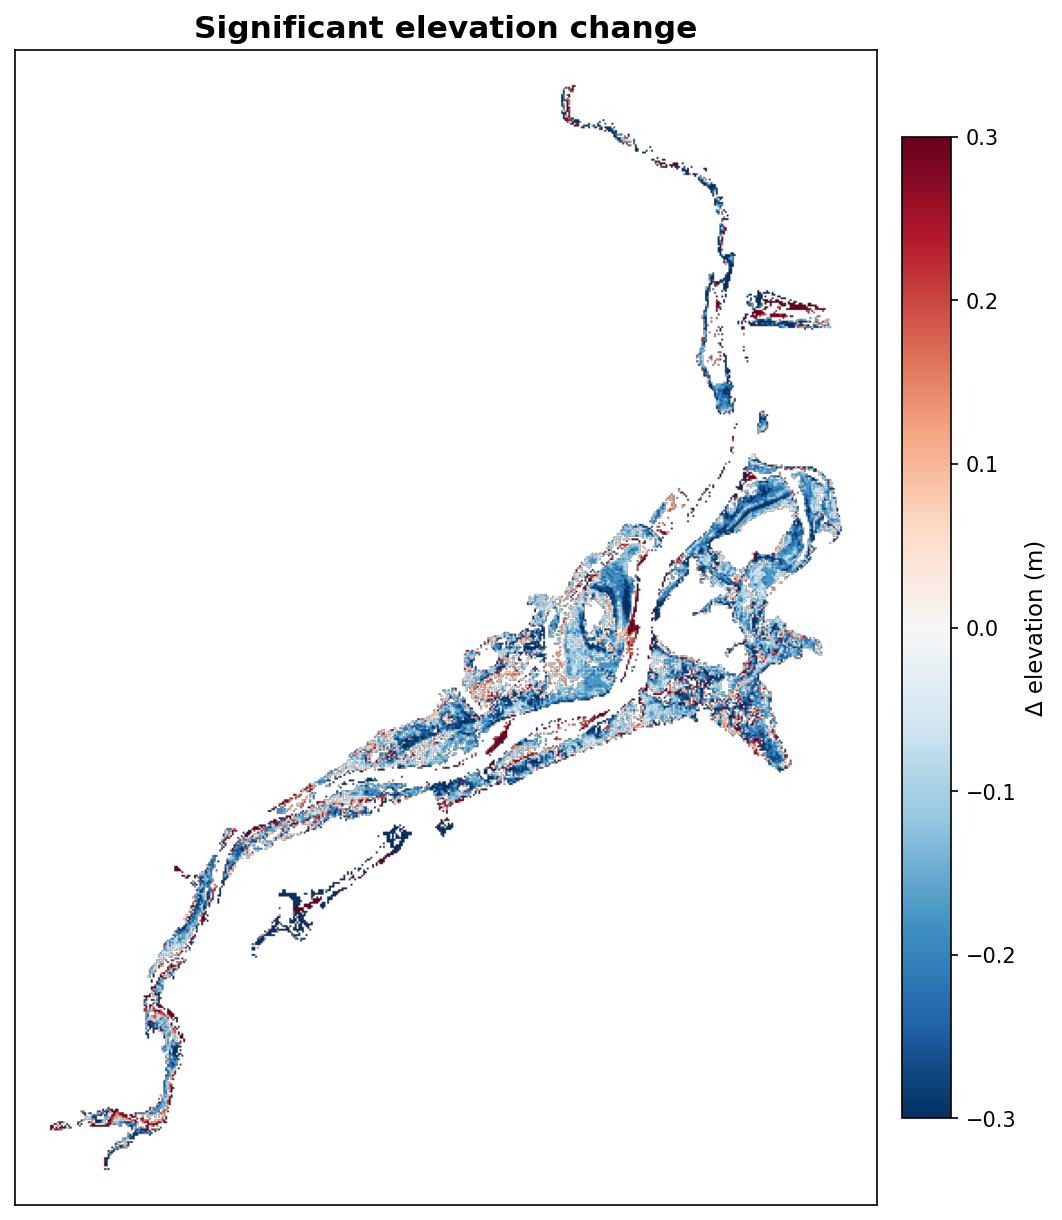

In [37]:
if len(epoch_list) >= 2:
    previous = epoch_list[-2]
    print(f"comparing {previous['label']} → {latest['label']}")

    dem_prev = pit.fit_hsr(cube, tide_heights, dates=previous["dates"],
                           scale=SCALE, max_uncertainty=MAX_UNCERTAINTY,
                           clip_mask=intertidal, epoch_label=previous["label"],
                           superresolve=False)

    change = pit.morphodynamics.dem_difference(
        dem_prev.mu, dem.mu, dem_prev.sigma_mu, dem.sigma_mu, confidence=1.96)
    budget = pit.morphodynamics.summarize(change, transform,
                                          f"{previous['label']} → {latest['label']}")

    viz.plot_map(np.where(change["significant"], change["change"], np.nan),
                 transform, crs, aoi, cmap="RdBu_r", vmin=-0.3, vmax=0.3,
                 robust=False, title="Significant elevation change",
                 cbar_label="Δ elevation (m)")
else:
    print("only one epoch available — skip the change analysis")

## 11 · Provenance and outputs

The process graph of everything above: which operations ran, in which order,
with which parameters. This is the figure that makes the study auditable by
somebody who did not run it.

In [38]:
explain.draw_graph(log)

<pyintertidal diagram: process graph · Villaviciosa 2016–2025 — display it in a notebook or call .save(path)>

In [39]:
log.table()

,step,operation,kind,inputs,outputs,note,params,seconds
0,1,acquire datacube,acquire,,cube,"1379 scenes, cached once",water=ndwi · resolution_m=10,0.0
1,2,reference map + cloud stats,reduce,cube,"reference map, cloud %",,stable_threshold=0.95 · buffer_px=10,0.0
2,3,filter dates,filter,,305 dates,+9% vs a global filter,cloud_threshold=0.1,0.0
3,4,water frequency,reduce,305 dates,water frequency,,min_obs=15 · threshold=0.0,0.0
4,5,intertidal mask,mask,,intertidal mask,3.08 km²,wf_low=0.05 · wf_high=0.95,0.0
5,6,tide heights,apply,,305 tide heights,,"model=EOT20 · point=43.540,-5.381 · ocean_cell...",0.0
6,7,HSR elevation,apply,"97 dates, tide heights","elevation, sub-pixel relief, uncertainty",,epoch=2023-2025 · scale=4 · tide_bins=auto · m...,0.0


Finally, write the products, package them with STAC metadata that carries the parameters, and build a single self-contained HTML report.

In [40]:
import os

# Rasters (10 m grid, clipped to the polygon) + the super-resolved DEM
dem.save(OUT_DIR)
pit.write_geotiff(f"{OUT_DIR}/water_frequency.tif", water_freq,
                  transform, crs, "float32", np.nan)
pit.write_geotiff(f"{OUT_DIR}/intertidal_mask.tif",
                  intertidal.astype("uint8"), transform, crs, "uint8", None)
pit.write_geotiff(f"{OUT_DIR}/hydroperiod.tif", hydro,
                  transform, crs, "float32", np.nan)

# Provenance travels with the data
item = pit.export.stac_item(
    f"{OUT_DIR}/hsr_elevation.tif", aoi=aoi,
    datetime_utc=f"{latest['label'][-4:]}-07-01",
    properties={"pyintertidal:method": "hsr",
                "pyintertidal:epoch": latest["label"],
                "pyintertidal:ndwi_threshold": NDWI_THRESHOLD,
                "pyintertidal:cloud_threshold": CLOUD_THRESHOLD,
                "pyintertidal:wf_window": [round(WF_LOW, 3), round(WF_HIGH, 3)],
                "pyintertidal:min_obs": MIN_OBS,
                "pyintertidal:tide_model": TIDE_MODEL,
                "pyintertidal:ocean_cell_km": round(ocean["distance_km"], 1)},
    assets={"uncertainty": f"{OUT_DIR}/hsr_uncertainty.tif",
            "subpixel_relief": f"{OUT_DIR}/hsr_sigma.tif"})
pit.export.write_stac([item], OUT_DIR,
                      description=f"Intertidal products · {aoi.name}")

# ── The cube is disposable; the products are not ────────────────────────
# A regional campaign of ~80 cells at ~1 GB each does not fit on this disk,
# and it does not need to: once the products exist the cube has served its
# purpose. Verify FIRST — every file opened and non-empty — because deleting
# a gigabyte on the strength of a filename that happens to exist is how a
# night's downloading disappears.
if EVICT_CUBE:
    import rasterio
    required = ["hsr_elevation.tif", "water_frequency.tif",
                "intertidal_mask.tif"]
    for name in required:
        path = f"{OUT_DIR}/{name}"
        with rasterio.open(path) as src:          # raises if unreadable
            if not np.isfinite(src.read(1)).any():
                raise RuntimeError(f"{path} opened but holds no data — "
                                   f"refusing to delete {CACHE}")
    size_gb = os.path.getsize(CACHE) / 1e9
    os.remove(CACHE)
    print(f"cube evicted: {CACHE} ({size_gb:.2f} GB) — "
          f"{len(required)} products verified first")


[export] STAC collection with 1 items → products_villaviciosa\collection.json

In [41]:
report_path = pit.report.site_report(
    f"{OUT_DIR}/report_villaviciosa.html",
    aoi, cube=cube,
    params={"period": f"{TIME_EXTENT[0]} → {TIME_EXTENT[1]}",
            "water detector": WATER, "NDWI threshold": NDWI_THRESHOLD,
            "cloud threshold": CLOUD_THRESHOLD, "min observations": MIN_OBS,
            "intertidal window": f"[{WF_LOW:.2f}, {WF_HIGH:.2f}]",
            "epoch": latest["label"], "tide model": TIDE_MODEL},
    coverage=metrics, verdict=verdict,
    validation=rows, zones=zone_table, oplog=log,
    notes="Satellite-derived intertidal topography, produced with pyintertidal.")

print("report written to", report_path)

report written to

products_villaviciosa/report_villaviciosa.html

## Notes

* **Scaling out.** This notebook *is* the production cell. `campaign_north_coast.ipynb`
  tiles the coast, replaces the parameters cell at the top, and executes this
  file once per cell with `nbclient`; each executed copy is kept as the
  provenance record of that cell. Set `EVICT_CUBE=True` there and the cube is
  deleted once its products are verified, so ~80 cells cost a few GB of disk
  instead of a hundred. `pyintertidal.mosaic` merges the results and measures
  the seams.
* **What is validated, and what is not.** The elevations here are checked
  against an RTK GNSS field survey, which is the only reference in this study
  that measures the bed rather than the water. The IGN LiDAR is shown in
  section 9 to demonstrate *why* it cannot arbitrate — seven distinct values
  across the flat, 83 % of them the water surface — not to rank the methods.
  Any earlier figure of ours quoting an RMSE "against IGN LiDAR" is withdrawn.
* **The limiting error is the tide, not the estimator.** HSR and the published
  step method tie against the field survey, and both compress relief in the
  same way and by the same amount. See `pyintertidal.tidecheck` for what an
  estuary does to the tide and, more usefully, for which parts of it a
  satellite can and cannot recover.
* **Reproducibility.** Every parameter in this notebook is a named variable,
  and the same values are stored in the STAC item and the HTML report, so a
  result found later can always be traced back to the run that made it.
